# modelo con 3 clases

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import re
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import itertools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multicomp import MultiComparison
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import shapiro, normaltest, anderson, jarque_bera
from scipy.stats import f_oneway, kruskal
from scipy.stats import levene, bartlett
warnings.filterwarnings('ignore')
from scipy.stats import spearmanr, kendalltau
from collections import defaultdict
from datetime import datetime
import os
from matplotlib.patches import Patch
from sklearn.preprocessing import LabelEncoder
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import ttest_ind
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import DBSCAN
from collections import Counter
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist, squareform
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from difflib import unified_diff, SequenceMatcher
import json

In [2]:
#1
# Cargar el archivo Excel (especifica la ruta correcta del archivo)
file_path = 'C:/Users/ville/datos_final_20_10.xlsx'  # Cambia esto por la ubicación de tu archivo
df = pd.read_excel(file_path)
print(df)

file_path_unlabel = 'C:/Users/ville/prueba_selftrain_20_10.xlsx'  # Cambia esto por la ubicación de tu archivo
X_unlabeled = pd.read_excel(file_path_unlabel)
print(df)

      Unnamed: 0   IDQ                     Faena    Recurso  Cu(g/t)  V(g/t)  \
0              0     1                LA PATAGUA      COBRE     1772      71   
1              1     2       LAS CENIZAS CABILDO      COBRE     2616      49   
2              2     3       LAS CENIZAS CABILDO      COBRE      814      86   
3              3     4       LAS CENIZAS CABILDO      COBRE      528      32   
4              4     5       LAS CENIZAS CABILDO      COBRE      627     104   
...          ...   ...                       ...        ...      ...     ...   
1995        2126  2195             PLANTA TORINO  COBRE-ORO     3297     286   
1996        2127  2196             PLANTA CARMEN  COBRE-ORO     2005     136   
1997        2128  2197             PLANTA CARMEN  COBRE-ORO     3247     131   
1998        2129  2198  PLANTA CALLEJAS VALLENAR  COBRE-ORO     2422     160   
1999        2130  2199  PLANTA CALLEJAS VALLENAR  COBRE-ORO     3131     239   

      Cr(g/t)  Co(g/t)  Ni(g/t)  Zn(g/t

In [3]:
#2
df_sin_faena = df.drop('Faena', axis=1)
df_sin_idq = df_sin_faena.drop('IDQ', axis=1)
df_sin_unn = df_sin_idq.drop('Unnamed: 0', axis=1)
df_cu_au = df_sin_unn

In [4]:
recursos_au_cu = print(df_cu_au['Recurso'].value_counts())

COBRE                  710
ORO                    648
COBRE-ORO              343
ORO-COBRE               90
COBRE-MOLIBDENO         57
ORO-COBRE-PLATA         35
COBRE-ORO-PLATA         29
CARBONATO DE CALCIO     16
ZINC-PLOMO              16
HIERRO                   8
CAOLIN                   8
ORO-PLATA                7
CALIZA                   6
ZINC                     5
PLATA-ORO                5
ORO-COBRE-ORO            4
ZINC-COBRE               4
COBRE-PLATA-ORO          3
COBRE-ORO-FIERRO         3
ORO-ZINC                 3
Name: Recurso, dtype: int64


In [5]:
print(df_cu_au.head())

  Recurso  Cu(g/t)  V(g/t)  Cr(g/t)  Co(g/t)  Ni(g/t)  Zn(g/t)  Rb(g/t)  \
0   COBRE     1772      71       21       35        7       90       62   
1   COBRE     2616      49       65       30       32      362       31   
2   COBRE      814      86       55       34       16      184       76   
3   COBRE      528      32       36       30       49       84       17   
4   COBRE      627     104       52       32       10       90       63   

   Sr(g/t)  Y(g/t)  ...  Gd(g/t)  Tb(g/t)  Dy(g/t)  Ho(g/t)  Er(g/t)  Tm(g/t)  \
0      144      10  ...     3.88     0.54     2.81     0.71     1.79     0.24   
1      161      10  ...     3.04     0.44     2.79     0.55     1.40     0.21   
2      210      10  ...     3.14     0.46     3.12     0.58     1.61     0.25   
3      110      10  ...     2.79     0.41     2.35     0.49     1.55     0.19   
4      189      10  ...     3.67     0.54     3.34     0.71     1.88     0.26   

   Yb(g/t)  Lu(g/t)  Au(g/t)  Hg(g/t)  
0     1.75     0.23   


MÉTODO 1: RFE con número fijo de features

Variables seleccionadas: 45

Ranking de variables (1 = mejor):
  Variable  Ranking  Seleccionada
   Cu(g/t)        1          True
  Al2O3(%)        1          True
   TiO2(%)        1          True
  Fe2O3(%)        1          True
    CaO(%)        1          True
    MgO(%)        1          True
    MnO(%)        1          True
   Na2O(%)        1          True
    K2O(%)        1          True
   P2O5(%)        1          True
    PPC(%)        1          True
   La(g/t)        1          True
   Ce(g/t)        1          True
   Pr(g/t)        1          True
   Nd(g/t)        1          True
   Sm(g/t)        1          True
   Eu(g/t)        1          True
   Gd(g/t)        1          True
   Dy(g/t)        1          True
   Ho(g/t)        1          True
   Er(g/t)        1          True
   Yb(g/t)        1          True
   SiO2(%)        1          True
   Cd(g/t)        1          True
S Total(%)        1          True
   Ba(g/t

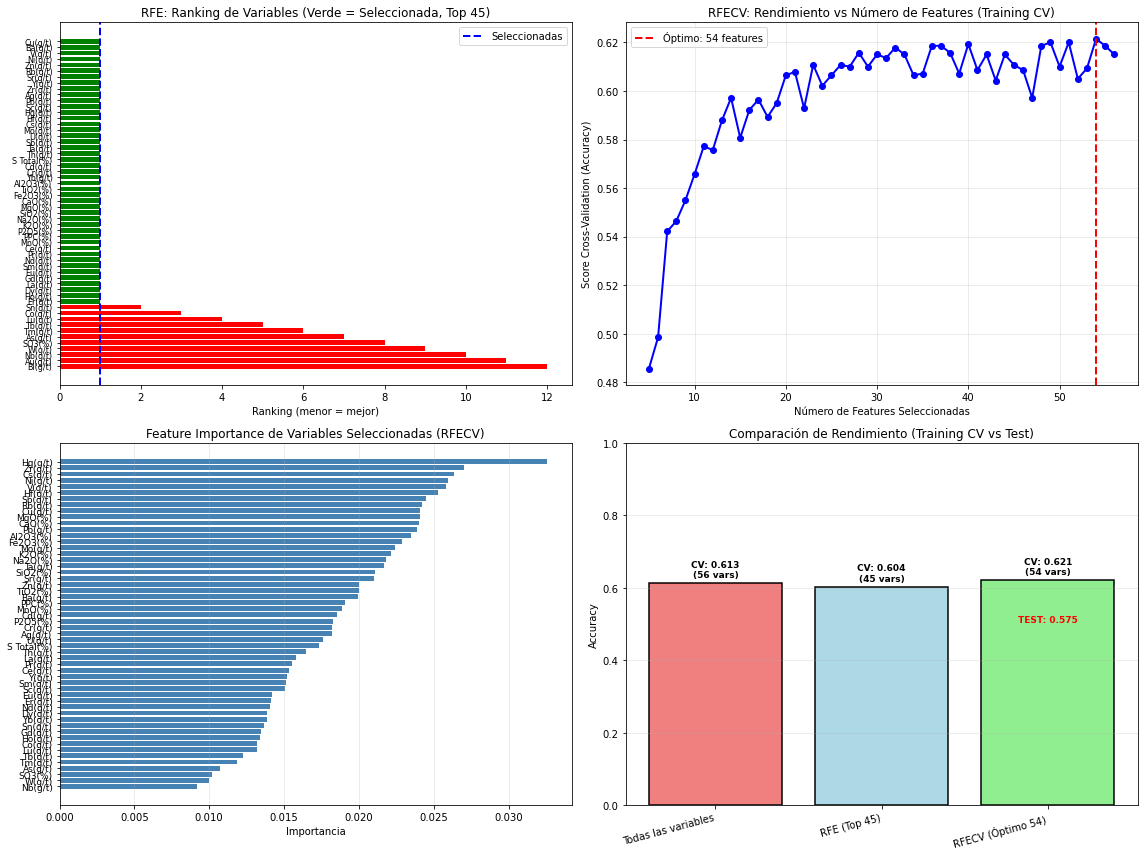


GUARDANDO RESULTADOS
✓ Ranking guardado en: rfe_ranking_variables.csv
✓ Variables seleccionadas guardadas en: variables_seleccionadas_rfecv.csv
✓ Dataset reducido guardado en: dataset_reducido_rfecv.csv
  (de 56 variables a 54 variables)
✓ Conjuntos de train y test reducidos guardados

ANÁLISIS COMPLETADO - SIN DATA LEAKAGE


In [6]:
#3 (6)

# Separar variables numéricas y clase categórica
X = df_cu_au.drop('Recurso', axis=1)  # Variables numéricas
y = df_cu_au['Recurso']  # Clase categórica

# Guardar copia del dataframe original para uso posterior
df_original = df_cu_au.copy()

# Separar en train/test (70/30) con el MISMO random_state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,
    random_state=42,  # ← MISMO que en Random Forest
    stratify=y
)

# Codificar clases categóricas a números (SOLO con training)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # Solo fit en train
y_test_encoded = le.transform(y_test)        # Solo transform en test

# Estandarizar variables (SOLO con training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Solo fit en train
X_test_scaled = scaler.transform(X_test)        # Solo transform en test

# Crear DataFrames escalados
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n" + "=" * 70)
print("MÉTODO 1: RFE con número fijo de features")
print("=" * 70)

# Definir el modelo estimador (puedes cambiar el modelo)
estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Número de features que quieres seleccionar
n_features_to_select = min(45, X_train.shape[1])  # Seleccionar 45 o menos si hay pocas

# RFE con número fijo (SOLO con training data)
rfe = RFE(estimator=estimator, n_features_to_select=n_features_to_select)
rfe.fit(X_train_scaled, y_train_encoded)  # ← SOLO training data

# Obtener ranking de variables
ranking_df = pd.DataFrame({
    'Variable': X.columns,
    'Ranking': rfe.ranking_,
    'Seleccionada': rfe.support_
}).sort_values('Ranking')

print(f"\nVariables seleccionadas: {sum(rfe.support_)}")
print("\nRanking de variables (1 = mejor):")
print(ranking_df.to_string(index=False))

# Variables seleccionadas
selected_features = X.columns[rfe.support_].tolist()
print(f"\n{'='*70}")
print(f"Top {n_features_to_select} variables seleccionadas:")
print(f"{'='*70}")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

print("\n" + "=" * 70)
print("MÉTODO 2: RFECV - Selección automática con Cross-Validation")
print("=" * 70)

# RFECV encuentra automáticamente el número óptimo de features (SOLO con training)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(
    estimator=estimator,
    step=1,  # Eliminar 1 variable a la vez
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    min_features_to_select=5  # Mínimo de features a mantener
)

rfecv.fit(X_train_scaled, y_train_encoded)  # ← SOLO training data

print(f"\nNúmero óptimo de features: {rfecv.n_features_}")
print(f"Mejor score (accuracy): {rfecv.cv_results_['mean_test_score'].max():.4f}")

# Variables seleccionadas por RFECV
selected_features_cv = X.columns[rfecv.support_].tolist()
print(f"\nVariables seleccionadas por RFECV:")
for i, feat in enumerate(selected_features_cv, 1):
    print(f"{i}. {feat}")

# Aplicar selección al conjunto de test
X_test_selected = X_test_scaled[:, rfecv.support_]

# Entrenar modelo final con features seleccionadas (SOLO training)
X_train_selected = X_train_scaled[:, rfecv.support_]
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_selected, y_train_encoded)

# Evaluar en test set
y_pred = final_model.predict(X_test_selected)
test_accuracy = accuracy_score(y_test_encoded, y_pred)

print(f"\n{'='*70}")
print("EVALUACIÓN EN TEST SET")
print(f"{'='*70}")
print(f"Accuracy en TEST: {test_accuracy:.4f}")


# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ranking de todas las variables (RFE)
ranking_sorted = ranking_df.sort_values('Ranking')
colors = ['green' if x else 'red' for x in ranking_sorted['Seleccionada']]
axes[0, 0].barh(range(len(ranking_sorted)), ranking_sorted['Ranking'], color=colors)
axes[0, 0].set_yticks(range(len(ranking_sorted)))
axes[0, 0].set_yticklabels(ranking_sorted['Variable'], fontsize=8)
axes[0, 0].set_xlabel('Ranking (menor = mejor)')
axes[0, 0].set_title(f'RFE: Ranking de Variables (Verde = Seleccionada, Top {n_features_to_select})')
axes[0, 0].invert_yaxis()
axes[0, 0].axvline(x=1, color='blue', linestyle='--', linewidth=2, label='Seleccionadas')
axes[0, 0].legend()

# 2. RFECV - Número de features vs Score
axes[0, 1].plot(range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
                rfecv.cv_results_['mean_test_score'], 'b-o', linewidth=2, markersize=6)
axes[0, 1].axvline(x=rfecv.n_features_, color='red', linestyle='--', 
                   linewidth=2, label=f'Óptimo: {rfecv.n_features_} features')
axes[0, 1].set_xlabel('Número de Features Seleccionadas')
axes[0, 1].set_ylabel('Score Cross-Validation (Accuracy)')
axes[0, 1].set_title('RFECV: Rendimiento vs Número de Features (Training CV)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Importancia de features seleccionadas (Feature Importance del modelo)
importance_df = pd.DataFrame({
    'Variable': selected_features_cv,
    'Importancia': final_model.feature_importances_
}).sort_values('Importancia', ascending=True)

axes[1, 0].barh(range(len(importance_df)), importance_df['Importancia'], color='steelblue')
axes[1, 0].set_yticks(range(len(importance_df)))
axes[1, 0].set_yticklabels(importance_df['Variable'], fontsize=9)
axes[1, 0].set_xlabel('Importancia')
axes[1, 0].set_title('Feature Importance de Variables Seleccionadas (RFECV)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Comparación de scores
comparison_data = {
    'Método': ['Todas las variables', f'RFE (Top {n_features_to_select})', 
               f'RFECV (Óptimo {rfecv.n_features_})'],
    'N° Features': [X.shape[1], n_features_to_select, rfecv.n_features_]
}

# Calcular scores usando SOLO training data
model_full = RandomForestClassifier(n_estimators=100, random_state=42)
score_full = cross_val_score(model_full, X_train_scaled, y_train_encoded, cv=5, scoring='accuracy').mean()

model_rfe = RandomForestClassifier(n_estimators=100, random_state=42)
score_rfe = cross_val_score(model_rfe, X_train_scaled[:, rfe.support_], y_train_encoded, cv=5, scoring='accuracy').mean()

# Después de la línea del test_accuracy de RFECV, agregar:

# Evaluar modelo con todas las variables en test
model_full_test = RandomForestClassifier(n_estimators=100, random_state=42)
model_full_test.fit(X_train_scaled, y_train_encoded)
y_pred_full = model_full_test.predict(X_test_scaled)
test_accuracy_full = accuracy_score(y_test_encoded, y_pred_full)

# Evaluar modelo RFE en test
model_rfe_test = RandomForestClassifier(n_estimators=100, random_state=42)
model_rfe_test.fit(X_train_scaled[:, rfe.support_], y_train_encoded)
y_pred_rfe = model_rfe_test.predict(X_test_scaled[:, rfe.support_])
test_accuracy_rfe = accuracy_score(y_test_encoded, y_pred_rfe)

# Actualizar la tabla
comparison_data['Accuracy Test'] = [test_accuracy_full, test_accuracy_rfe, test_accuracy]


comparison_data['Accuracy CV'] = [score_full, score_rfe, rfecv.cv_results_['mean_test_score'].max()]


comparison_df = pd.DataFrame(comparison_data)
print(f"\n{'='*70}")
print("COMPARACIÓN DE RENDIMIENTO")
print(f"{'='*70}")
print(comparison_df.to_string(index=False))

# Gráfico de comparación
x_pos = range(len(comparison_df))
colors_comp = ['lightcoral', 'lightblue', 'lightgreen']
bars = axes[1, 1].bar(x_pos, comparison_df['Accuracy CV'], color=colors_comp, edgecolor='black', linewidth=1.5)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(comparison_df['Método'], rotation=15, ha='right')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Comparación de Rendimiento (Training CV vs Test)')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, (bar, acc_cv, n_feat) in enumerate(zip(bars, comparison_df['Accuracy CV'], comparison_df['N° Features'])):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'CV: {acc_cv:.3f}\n({n_feat} vars)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Añadir resultado de test para RFECV
axes[1, 1].text(2, test_accuracy - 0.05,
                f'TEST: {test_accuracy:.3f}',
                ha='center', va='top', fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('rfe_analisis_sin_leakage.png', dpi=300, bbox_inches='tight')
plt.show()

# Guardar resultados
print(f"\n{'='*70}")
print("GUARDANDO RESULTADOS")
print(f"{'='*70}")

# Guardar ranking completo
ranking_df.to_csv('rfe_ranking_variables.csv', index=False)
print("✓ Ranking guardado en: rfe_ranking_variables.csv")

# Guardar variables seleccionadas
pd.DataFrame({'Variable': selected_features_cv}).to_csv('variables_seleccionadas_rfecv.csv', index=False)
print("✓ Variables seleccionadas guardadas en: variables_seleccionadas_rfecv.csv")

# Guardar dataset reducido - usar el dataframe original
X_reduced = df_original[selected_features_cv + ['Recurso']].copy()
X_reduced.to_csv('dataset_reducido_rfecv.csv', index=False)
print(f"✓ Dataset reducido guardado en: dataset_reducido_rfecv.csv")
print(f"  (de {X.shape[1]} variables a {len(selected_features_cv)} variables)")

# Guardar también los conjuntos de train y test procesados
X_train_reduced = pd.DataFrame(X_train_scaled[:, rfecv.support_], columns=selected_features_cv)
X_train_reduced['Recurso'] = y_train_encoded
X_train_reduced.to_csv('train_reducido_rfecv.csv', index=False)

X_test_reduced = pd.DataFrame(X_test_scaled[:, rfecv.support_], columns=selected_features_cv)
X_test_reduced['Recurso'] = y_test_encoded
X_test_reduced.to_csv('test_reducido_rfecv.csv', index=False)

print("✓ Conjuntos de train y test reducidos guardados")

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETADO - SIN DATA LEAKAGE")
print("=" * 70)


ANÁLISIS UMAP - FILTRADO PARA COBRE Y ORO
Dimensiones después del filtrado:
- Train original: (1400, 56) -> Train filtrado: (951, 56)
- Test original: (600, 56) -> Test filtrado: (407, 56)
- Clases en train: (array(['COBRE', 'ORO'], dtype=object), array([497, 454], dtype=int64))
- Clases en test: (array(['COBRE', 'ORO'], dtype=object), array([213, 194], dtype=int64))
Aplicando UMAP a datos filtrados...
✓ UMAP completado


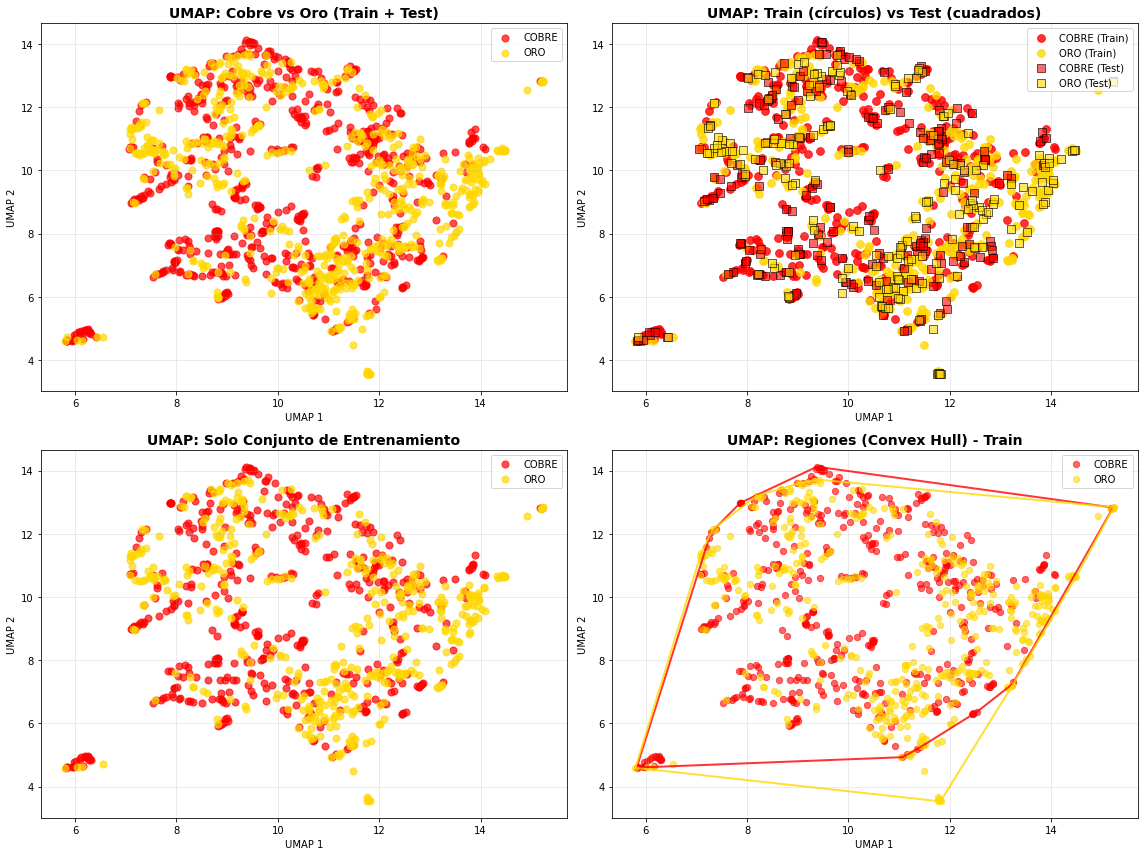


MÉTRICAS DE CALIDAD UMAP - COBRE vs ORO
UMAP - Conjunto de Entrenamiento (Cobre vs Oro):
  • Silhouette Score: 0.0258
  • Calinski-Harabasz Score: 19.5443
  • Interpretación: Alto solapamiento entre Cobre y Oro

Análisis de clusters (UMAP - Train):
  • COBRE: 497 muestras
    Centroide: [10.059, 9.631]
    Desviación: [1.910, 2.513]
  • ORO: 454 muestras
    Centroide: [10.904, 9.306]
    Desviación: [2.049, 2.388]
  • Distancia entre centroides: 0.906

GUARDANDO RESULTADOS UMAP - COBRE Y ORO
✓ Coordenadas UMAP guardadas en: coordenadas_umap_cobre_oro.csv
✓ Métricas UMAP guardadas en: metricas_umap_cobre_oro.csv

Resumen UMAP - Cobre vs Oro:
• Muestras totales: 1358 (Train: 951, Test: 407)
• Silhouette Score: 0.0258
• Separación: Alto solapamiento entre Cobre y Oro

ANÁLISIS UMAP COMPLETADO - COBRE Y ORO


In [7]:
#4
# =============================================================================
# ANÁLISIS UMAP - COBRE, COBRE-ORO Y ORO
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS UMAP - FILTRADO PARA COBRE Y ORO")
print("=" * 70)

import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# Filtrar solo las clases Cobre y Oro
clases_deseadas = ['COBRE', 'ORO', 'COBRE-ORO']  # Ajusta los nombres según tus datos

# Crear máscaras para filtrar
mask_train = np.isin(y_train, clases_deseadas)
mask_test = np.isin(y_test, clases_deseadas)

# Aplicar filtro a los datos
X_train_filtered = X_train_scaled[mask_train]
y_train_filtered = y_train[mask_train]
X_test_filtered = X_test_scaled[mask_test]
y_test_filtered = y_test[mask_test]

# Codificar las clases filtradas
y_train_filtered_encoded = le.transform(y_train_filtered)
y_test_filtered_encoded = le.transform(y_test_filtered)

# Aplicar selección de features a los datos filtrados
X_train_selected = X_train_filtered[:, rfecv.support_]
X_test_selected = X_test_filtered[:, rfecv.support_]

# Combinar train + test para visualización completa
X_combined_selected = np.vstack([X_train_selected, X_test_selected])
y_combined_encoded = np.hstack([y_train_filtered_encoded, y_test_filtered_encoded])
y_combined_original = np.hstack([y_train_filtered, y_test_filtered])

print(f"Dimensiones después del filtrado:")
print(f"- Train original: {X_train_scaled.shape} -> Train filtrado: {X_train_filtered.shape}")
print(f"- Test original: {X_test_scaled.shape} -> Test filtrado: {X_test_filtered.shape}")
print(f"- Clases en train: {np.unique(y_train_filtered, return_counts=True)}")
print(f"- Clases en test: {np.unique(y_test_filtered, return_counts=True)}")

# Configurar UMAP
umap_reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean'
)

# Aplicar UMAP a datos filtrados
print("Aplicando UMAP a datos filtrados...")
X_umap = umap_reducer.fit_transform(X_combined_selected)
print("✓ UMAP completado")

# Identificar índices de train y test filtrados
train_size = len(X_train_selected)
test_size = len(X_test_selected)

# =============================================================================
# VISUALIZACIONES UMAP (COBRE Y ORO)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Paleta de colores para Cobre y Oro
palette = {'COBRE': 'red', 'ORO': 'gold'}  # Colores apropiados para metales

# 1. UMAP - Todos los datos combinados (Cobre y Oro)
for class_name in clases_deseadas:
    mask = y_combined_original == class_name
    color = palette[class_name]
    axes[0, 0].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        color=color,
        label=class_name,
        alpha=0.7,
        s=50
    )
axes[0, 0].set_title('UMAP: Cobre vs Oro (Train + Test)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('UMAP 1')
axes[0, 0].set_ylabel('UMAP 2')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 2. UMAP - Separado por Train/Test
# Train points
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    color = palette[class_name]
    axes[0, 1].scatter(
        X_umap[:train_size, 0][mask], X_umap[:train_size, 1][mask],
        color=color,
        label=f'{class_name} (Train)',
        alpha=0.8,
        s=60,
        marker='o'
    )

# Test points
for class_name in clases_deseadas:
    mask = (y_test_filtered == class_name)
    color = palette[class_name]
    axes[0, 1].scatter(
        X_umap[train_size:, 0][mask], X_umap[train_size:, 1][mask],
        color=color,
        label=f'{class_name} (Test)',
        alpha=0.6,
        s=70,
        marker='s',
        edgecolor='black',
        linewidth=1.0
    )

axes[0, 1].set_title('UMAP: Train (círculos) vs Test (cuadrados)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('UMAP 1')
axes[0, 1].set_ylabel('UMAP 2')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# 3. UMAP - Solo Train (para análisis de clusters)
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    color = palette[class_name]
    axes[1, 0].scatter(
        X_umap[:train_size, 0][mask], X_umap[:train_size, 1][mask],
        color=color,
        label=class_name,
        alpha=0.7,
        s=50
    )
axes[1, 0].set_title('UMAP: Solo Conjunto de Entrenamiento', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('UMAP 1')
axes[1, 0].set_ylabel('UMAP 2')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# 4. UMAP - Convex Hull para mostrar regiones
from scipy.spatial import ConvexHull
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    if np.sum(mask) >= 3:  # Mínimo 3 puntos para convex hull
        points = X_umap[:train_size][mask]
        hull = ConvexHull(points)
        color = palette[class_name]
        
        # Dibujar el convex hull
        for simplex in hull.simplices:
            axes[1, 1].plot(points[simplex, 0], points[simplex, 1], 
                           color=color, linewidth=2, alpha=0.8)
        
        # Dibujar puntos
        axes[1, 1].scatter(
            points[:, 0], points[:, 1],
            color=color,
            label=class_name,
            alpha=0.6,
            s=40
        )

axes[1, 1].set_title('UMAP: Regiones (Convex Hull) - Train', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('UMAP 1')
axes[1, 1].set_ylabel('UMAP 2')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('umap_cobre_oro.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# MÉTRICAS UMAP PARA COBRE Y ORO
# =============================================================================

print("\n" + "=" * 70)
print("MÉTRICAS DE CALIDAD UMAP - COBRE vs ORO")
print("=" * 70)

# Calcular métricas para UMAP (solo train filtrado)
silhouette_umap = silhouette_score(X_umap[:train_size], y_train_filtered_encoded)
calinski_umap = calinski_harabasz_score(X_umap[:train_size], y_train_filtered_encoded)

print(f"UMAP - Conjunto de Entrenamiento (Cobre vs Oro):")
print(f"  • Silhouette Score: {silhouette_umap:.4f}")
print(f"  • Calinski-Harabasz Score: {calinski_umap:.4f}")

# Interpretación del Silhouette Score
if silhouette_umap > 0.7:
    interpretation = "Separación excelente entre Cobre y Oro"
elif silhouette_umap > 0.5:
    interpretation = "Buena separación entre Cobre y Oro"
elif silhouette_umap > 0.25:
    interpretation = "Separación moderada, algo de solapamiento"
else:
    interpretation = "Alto solapamiento entre Cobre y Oro"

print(f"  • Interpretación: {interpretation}")

# =============================================================================
# ANÁLISIS ADICIONAL: DISTANCIAS ENTRE CLUSTERS
# =============================================================================

print(f"\nAnálisis de clusters (UMAP - Train):")
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    n_samples = np.sum(mask)
    if n_samples > 0:
        class_points = X_umap[:train_size][mask]
        centroid = np.mean(class_points, axis=0)
        std = np.std(class_points, axis=0)
        print(f"  • {class_name}: {n_samples} muestras")
        print(f"    Centroide: [{centroid[0]:.3f}, {centroid[1]:.3f}]")
        print(f"    Desviación: [{std[0]:.3f}, {std[1]:.3f}]")

# Calcular distancia entre centroides
if len(clases_deseadas) == 2:
    mask_cobre = (y_train_filtered == clases_deseadas[0])
    mask_oro = (y_train_filtered == clases_deseadas[1])
    
    centroide_cobre = np.mean(X_umap[:train_size][mask_cobre], axis=0)
    centroide_oro = np.mean(X_umap[:train_size][mask_oro], axis=0)
    
    distancia = np.linalg.norm(centroide_cobre - centroide_oro)
    print(f"  • Distancia entre centroides: {distancia:.3f}")

# =============================================================================
# GUARDAR RESULTADOS UMAP
# =============================================================================

print("\n" + "=" * 70)
print("GUARDANDO RESULTADOS UMAP - COBRE Y ORO")
print("=" * 70)

# Crear DataFrame con las coordenadas UMAP
umap_coordinates = pd.DataFrame({
    'Dataset': ['train'] * train_size + ['test'] * test_size,
    'Clase_Original': y_combined_original,
    'Clase_Encoded': y_combined_encoded,
    'UMAP_1': X_umap[:, 0],
    'UMAP_2': X_umap[:, 1]
})

# Guardar coordenadas
umap_coordinates.to_csv('coordenadas_umap_cobre_oro.csv', index=False)
print("✓ Coordenadas UMAP guardadas en: coordenadas_umap_cobre_oro.csv")

# Guardar métricas
umap_metrics = pd.DataFrame({
    'Metrica': ['Silhouette_Score', 'Calinski_Harabasz_Score', 'Distancia_Centroides'],
    'Valor': [silhouette_umap, calinski_umap, distancia],
    'Interpretacion': [interpretation, 'Mayor valor = mejor separación', 'Distancia entre clusters']
})

umap_metrics.to_csv('metricas_umap_cobre_oro.csv', index=False)
print("✓ Métricas UMAP guardadas en: metricas_umap_cobre_oro.csv")

print(f"\nResumen UMAP - Cobre vs Oro:")
print(f"• Muestras totales: {len(X_combined_selected)} (Train: {train_size}, Test: {test_size})")
print(f"• Silhouette Score: {silhouette_umap:.4f}")
print(f"• Separación: {interpretation}")

print("\n" + "=" * 70)
print("ANÁLISIS UMAP COMPLETADO - COBRE Y ORO")
print("=" * 70)


ANÁLISIS t-SNE - FILTRADO PARA COBRE Y ORO
Usando datos filtrados para t-SNE:
- Train: (951, 54)
- Test: (407, 54)
Aplicando t-SNE a datos filtrados...
✓ t-SNE completado


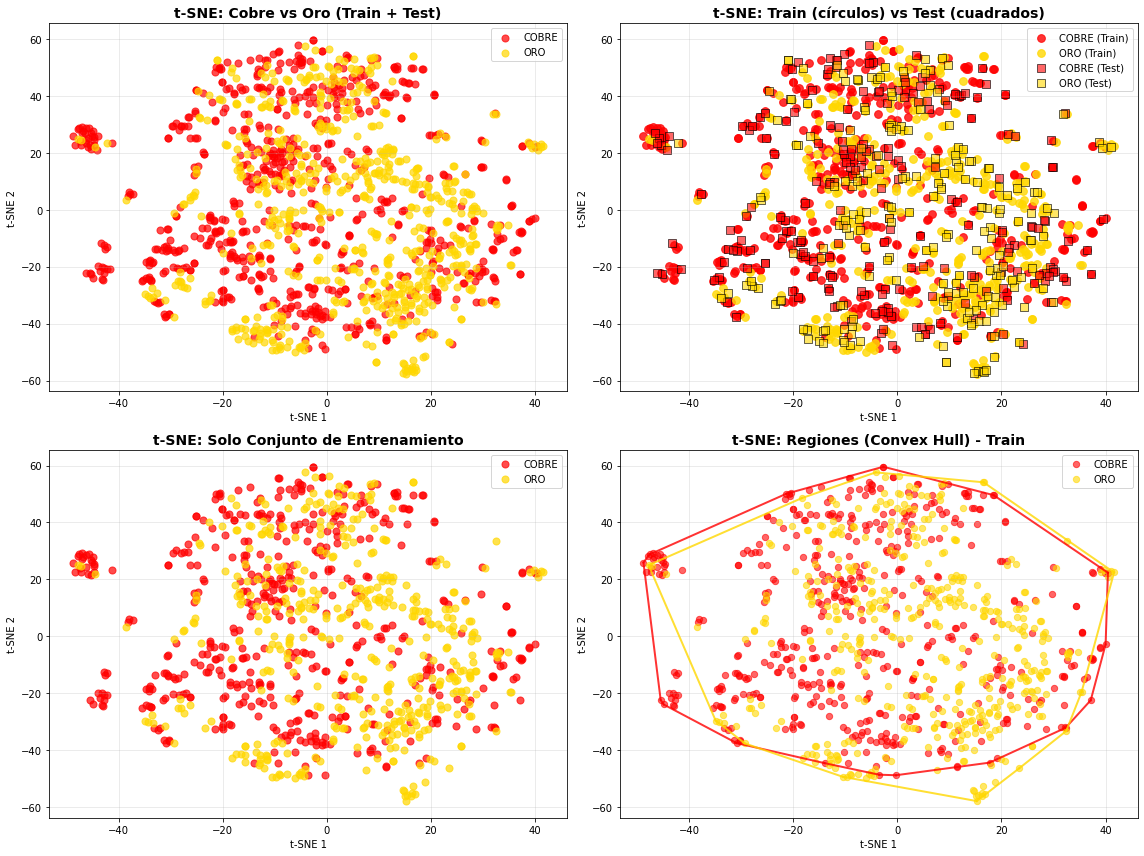


MÉTRICAS DE CALIDAD t-SNE - COBRE vs ORO
t-SNE - Conjunto de Entrenamiento (Cobre vs Oro):
  • Silhouette Score: 0.0351
  • Calinski-Harabasz Score: 31.8050
  • Interpretación: Alto solapamiento entre Cobre y Oro

Análisis de clusters (t-SNE - Train):
  • COBRE: 497 muestras
    Centroide: [-6.311, 4.722]
    Desviación: [20.627, 28.735]
  • ORO: 454 muestras
    Centroide: [4.408, -1.853]
    Desviación: [16.512, 28.691]
  • Distancia entre centroides: 12.574

GUARDANDO RESULTADOS t-SNE - COBRE Y ORO
✓ Coordenadas t-SNE guardadas en: coordenadas_tsne_cobre_oro.csv
✓ Métricas t-SNE guardadas en: metricas_tsne_cobre_oro.csv

Resumen t-SNE - Cobre vs Oro:
• Muestras totales: 1358 (Train: 951, Test: 407)
• Silhouette Score: 0.0351
• Separación: Alto solapamiento entre Cobre y Oro

ANÁLISIS t-SNE COMPLETADO - COBRE Y ORO


In [11]:
#5
# =============================================================================
# ANÁLISIS t-SNE - SOLO COBRE Y ORO
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS t-SNE - FILTRADO PARA COBRE Y ORO")
print("=" * 70)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.spatial import ConvexHull

# Usar los mismos datos filtrados que en UMAP
print(f"Usando datos filtrados para t-SNE:")
print(f"- Train: {X_train_selected.shape}")
print(f"- Test: {X_test_selected.shape}")

# Configurar t-SNE
tsne_reducer = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, train_size - 1),  # Ajustar perplexity según tamaño
    learning_rate=200,
    n_iter=1000
)

# Aplicar t-SNE a datos filtrados
print("Aplicando t-SNE a datos filtrados...")
X_tsne = tsne_reducer.fit_transform(X_combined_selected)
print("✓ t-SNE completado")

# =============================================================================
# VISUALIZACIONES t-SNE (COBRE Y ORO)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Paleta de colores para Cobre y Oro
palette = {'COBRE': 'red', 'ORO': 'gold'}

# 1. t-SNE - Todos los datos combinados (Cobre y Oro)
for class_name in clases_deseadas:
    mask = y_combined_original == class_name
    color = palette[class_name]
    axes[0, 0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        color=color,
        label=class_name,
        alpha=0.7,
        s=50
    )
axes[0, 0].set_title('t-SNE: Cobre vs Oro (Train + Test)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 2. t-SNE - Separado por Train/Test
# Train points
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    color = palette[class_name]
    axes[0, 1].scatter(
        X_tsne[:train_size, 0][mask], X_tsne[:train_size, 1][mask],
        color=color,
        label=f'{class_name} (Train)',
        alpha=0.8,
        s=60,
        marker='o'
    )

# Test points
for class_name in clases_deseadas:
    mask = (y_test_filtered == class_name)
    color = palette[class_name]
    axes[0, 1].scatter(
        X_tsne[train_size:, 0][mask], X_tsne[train_size:, 1][mask],
        color=color,
        label=f'{class_name} (Test)',
        alpha=0.6,
        s=70,
        marker='s',
        edgecolor='black',
        linewidth=1.0
    )

axes[0, 1].set_title('t-SNE: Train (círculos) vs Test (cuadrados)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# 3. t-SNE - Solo Train (para análisis de clusters)
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    color = palette[class_name]
    axes[1, 0].scatter(
        X_tsne[:train_size, 0][mask], X_tsne[:train_size, 1][mask],
        color=color,
        label=class_name,
        alpha=0.7,
        s=50
    )
axes[1, 0].set_title('t-SNE: Solo Conjunto de Entrenamiento', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# 4. t-SNE - Convex Hull para mostrar regiones
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    if np.sum(mask) >= 3:  # Mínimo 3 puntos para convex hull
        points = X_tsne[:train_size][mask]
        hull = ConvexHull(points)
        color = palette[class_name]
        
        # Dibujar el convex hull
        for simplex in hull.simplices:
            axes[1, 1].plot(points[simplex, 0], points[simplex, 1], 
                           color=color, linewidth=2, alpha=0.8)
        
        # Dibujar puntos
        axes[1, 1].scatter(
            points[:, 0], points[:, 1],
            color=color,
            label=class_name,
            alpha=0.6,
            s=40
        )

axes[1, 1].set_title('t-SNE: Regiones (Convex Hull) - Train', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsne_cobre_oro.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# MÉTRICAS t-SNE PARA COBRE Y ORO
# =============================================================================

print("\n" + "=" * 70)
print("MÉTRICAS DE CALIDAD t-SNE - COBRE vs ORO")
print("=" * 70)

# Calcular métricas para t-SNE (solo train filtrado)
silhouette_tsne = silhouette_score(X_tsne[:train_size], y_train_filtered_encoded)
calinski_tsne = calinski_harabasz_score(X_tsne[:train_size], y_train_filtered_encoded)

print(f"t-SNE - Conjunto de Entrenamiento (Cobre vs Oro):")
print(f"  • Silhouette Score: {silhouette_tsne:.4f}")
print(f"  • Calinski-Harabasz Score: {calinski_tsne:.4f}")

# Interpretación del Silhouette Score
if silhouette_tsne > 0.7:
    interpretation = "Separación excelente entre Cobre y Oro"
elif silhouette_tsne > 0.5:
    interpretation = "Buena separación entre Cobre y Oro"
elif silhouette_tsne > 0.25:
    interpretation = "Separación moderada, algo de solapamiento"
else:
    interpretation = "Alto solapamiento entre Cobre y Oro"

print(f"  • Interpretación: {interpretation}")

# =============================================================================
# ANÁLISIS ADICIONAL: DISTANCIAS ENTRE CLUSTERS
# =============================================================================

print(f"\nAnálisis de clusters (t-SNE - Train):")
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    n_samples = np.sum(mask)
    if n_samples > 0:
        class_points = X_tsne[:train_size][mask]
        centroid = np.mean(class_points, axis=0)
        std = np.std(class_points, axis=0)
        print(f"  • {class_name}: {n_samples} muestras")
        print(f"    Centroide: [{centroid[0]:.3f}, {centroid[1]:.3f}]")
        print(f"    Desviación: [{std[0]:.3f}, {std[1]:.3f}]")

# Calcular distancia entre centroides
if len(clases_deseadas) == 2:
    mask_cobre = (y_train_filtered == clases_deseadas[0])
    mask_oro = (y_train_filtered == clases_deseadas[1])
    
    centroide_cobre = np.mean(X_tsne[:train_size][mask_cobre], axis=0)
    centroide_oro = np.mean(X_tsne[:train_size][mask_oro], axis=0)
    
    distancia_tsne = np.linalg.norm(centroide_cobre - centroide_oro)
    print(f"  • Distancia entre centroides: {distancia_tsne:.3f}")

# =============================================================================
# GUARDAR RESULTADOS t-SNE
# =============================================================================

print("\n" + "=" * 70)
print("GUARDANDO RESULTADOS t-SNE - COBRE Y ORO")
print("=" * 70)

# Crear DataFrame con las coordenadas t-SNE
tsne_coordinates = pd.DataFrame({
    'Dataset': ['train'] * train_size + ['test'] * test_size,
    'Clase_Original': y_combined_original,
    'Clase_Encoded': y_combined_encoded,
    'tSNE_1': X_tsne[:, 0],
    'tSNE_2': X_tsne[:, 1]
})

# Guardar coordenadas
tsne_coordinates.to_csv('coordenadas_tsne_cobre_oro.csv', index=False)
print("✓ Coordenadas t-SNE guardadas en: coordenadas_tsne_cobre_oro.csv")

# Guardar métricas
tsne_metrics = pd.DataFrame({
    'Metrica': ['Silhouette_Score', 'Calinski_Harabasz_Score', 'Distancia_Centroides'],
    'Valor': [silhouette_tsne, calinski_tsne, distancia_tsne],
    'Interpretacion': [interpretation, 'Mayor valor = mejor separación', 'Distancia entre clusters']
})

tsne_metrics.to_csv('metricas_tsne_cobre_oro.csv', index=False)
print("✓ Métricas t-SNE guardadas en: metricas_tsne_cobre_oro.csv")

print(f"\nResumen t-SNE - Cobre vs Oro:")
print(f"• Muestras totales: {len(X_combined_selected)} (Train: {train_size}, Test: {test_size})")
print(f"• Silhouette Score: {silhouette_tsne:.4f}")
print(f"• Separación: {interpretation}")

print("\n" + "=" * 70)
print("ANÁLISIS t-SNE COMPLETADO - COBRE Y ORO")
print("=" * 70)

In [12]:
#6
# =============================================================================
# ANÁLISIS DE SEPARACIÓN LINEAL vs NO LINEAL
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS: ¿SEPARACIÓN LINEAL O NO LINEAL?")
print("=" * 70)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from scipy.spatial import ConvexHull
import seaborn as sns

def analizar_separacion_lineal(X_embeddings, y, clases, metodo_nombre):
    """
    Analiza si la separación entre clases es lineal o no lineal
    """
    print(f"\n{'='*50}")
    print(f"ANÁLISIS PARA: {metodo_nombre}")
    print(f"{'='*50}")
    
    # 1. CLASIFICADOR LINEAL (Logistic Regression)
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_embeddings, y)
    y_pred_lr = lr_model.predict(X_embeddings)
    acc_lr = accuracy_score(y, y_pred_lr)
    
    # 2. CLASIFICADOR NO LINEAL (SVM con RBF)
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_embeddings, y)
    y_pred_svm = svm_model.predict(X_embeddings)
    acc_svm = accuracy_score(y, y_pred_svm)
    
    # 3. ANÁLISIS GEOMÉTRICO
    # Calcular solapamiento de convex hulls
    hulls = []
    areas = []
    for clase in np.unique(y):
        points = X_embeddings[y == clase]
        if len(points) >= 3:
            hull = ConvexHull(points)
            hulls.append(hull)
            areas.append(hull.volume)  # Área/volumen del convex hull
    
    # 4. DISTANCIA ENTRE CENTROIDES vs VARIABILIDAD INTRACLASE
    centroides = []
    varianzas = []
    for clase in np.unique(y):
        points = X_embeddings[y == clase]
        centroide = np.mean(points, axis=0)
        varianza = np.mean(np.var(points, axis=0))
        centroides.append(centroide)
        varianzas.append(varianza)
    
    distancia_centroides = np.linalg.norm(centroides[0] - centroides[1])
    varianza_promedio = np.mean(varianzas)
    ratio_separacion = distancia_centroides / varianza_promedio
    
    # 5. DETERMINAR TIPO DE SEPARACIÓN
    diferencia_precision = acc_svm - acc_lr
    es_lineal = diferencia_precision < 0.1  # Umbral ajustable
    
    print(f"Resultados:")
    print(f"  • Precisión Regresión Logística: {acc_lr:.4f}")
    print(f"  • Precisión SVM RBF: {acc_svm:.4f}")
    print(f"  • Diferencia: {diferencia_precision:.4f}")
    print(f"  • Distancia entre centroides: {distancia_centroides:.4f}")
    print(f"  • Variabilidad intra-clase promedio: {varianza_promedio:.4f}")
    print(f"  • Ratio separación: {ratio_separacion:.4f}")
    
    if es_lineal:
        print(f"  • CONCLUSIÓN: SEPARACIÓN PREDOMINANTEMENTE LINEAL")
        if ratio_separacion > 3:
            print(f"  • Las clases están BIEN SEPARADAS linealmente")
        else:
            print(f"  • Las clases están DÉBILMENTE SEPARADAS linealmente")
    else:
        print(f"  • CONCLUSIÓN: SEPARACIÓN NO LINEAL")
        if diferencia_precision > 0.2:
            print(f"  • SEPARACIÓN FUERTEMENTE NO LINEAL")
        else:
            print(f"  • SEPARACIÓN MODERADAMENTE NO LINEAL")
    
    return {
        'metodo': metodo_nombre,
        'precision_lineal': acc_lr,
        'precision_no_lineal': acc_svm,
        'diferencia': diferencia_precision,
        'distancia_centroides': distancia_centroides,
        'ratio_separacion': ratio_separacion,
        'es_lineal': es_lineal
    }

# Aplicar análisis a UMAP y t-SNE
resultados = []

# Para UMAP (solo datos de entrenamiento)
print("\nAnalizando separación en espacio UMAP...")
resultado_umap = analizar_separacion_lineal(
    X_umap[:train_size], 
    y_train_filtered_encoded, 
    clases_deseadas,
    "UMAP"
)
resultados.append(resultado_umap)

# Para t-SNE (solo datos de entrenamiento)
print("\nAnalizando separación en espacio t-SNE...")
resultado_tsne = analizar_separacion_lineal(
    X_tsne[:train_size], 
    y_train_filtered_encoded, 
    clases_deseadas,
    "t-SNE"
)
resultados.append(resultado_tsne)


ANÁLISIS: ¿SEPARACIÓN LINEAL O NO LINEAL?

Analizando separación en espacio UMAP...

ANÁLISIS PARA: UMAP
Resultados:
  • Precisión Regresión Logística: 0.6351
  • Precisión SVM RBF: 0.6656
  • Diferencia: 0.0305
  • Distancia entre centroides: 0.9055
  • Variabilidad intra-clase promedio: 4.9659
  • Ratio separación: 0.1823
  • CONCLUSIÓN: SEPARACIÓN PREDOMINANTEMENTE LINEAL
  • Las clases están DÉBILMENTE SEPARADAS linealmente

Analizando separación en espacio t-SNE...

ANÁLISIS PARA: t-SNE
Resultados:
  • Precisión Regresión Logística: 0.6204
  • Precisión SVM RBF: 0.6772
  • Diferencia: 0.0568
  • Distancia entre centroides: 12.5743
  • Variabilidad intra-clase promedio: 586.7627
  • Ratio separación: 0.0214
  • CONCLUSIÓN: SEPARACIÓN PREDOMINANTEMENTE LINEAL
  • Las clases están DÉBILMENTE SEPARADAS linealmente


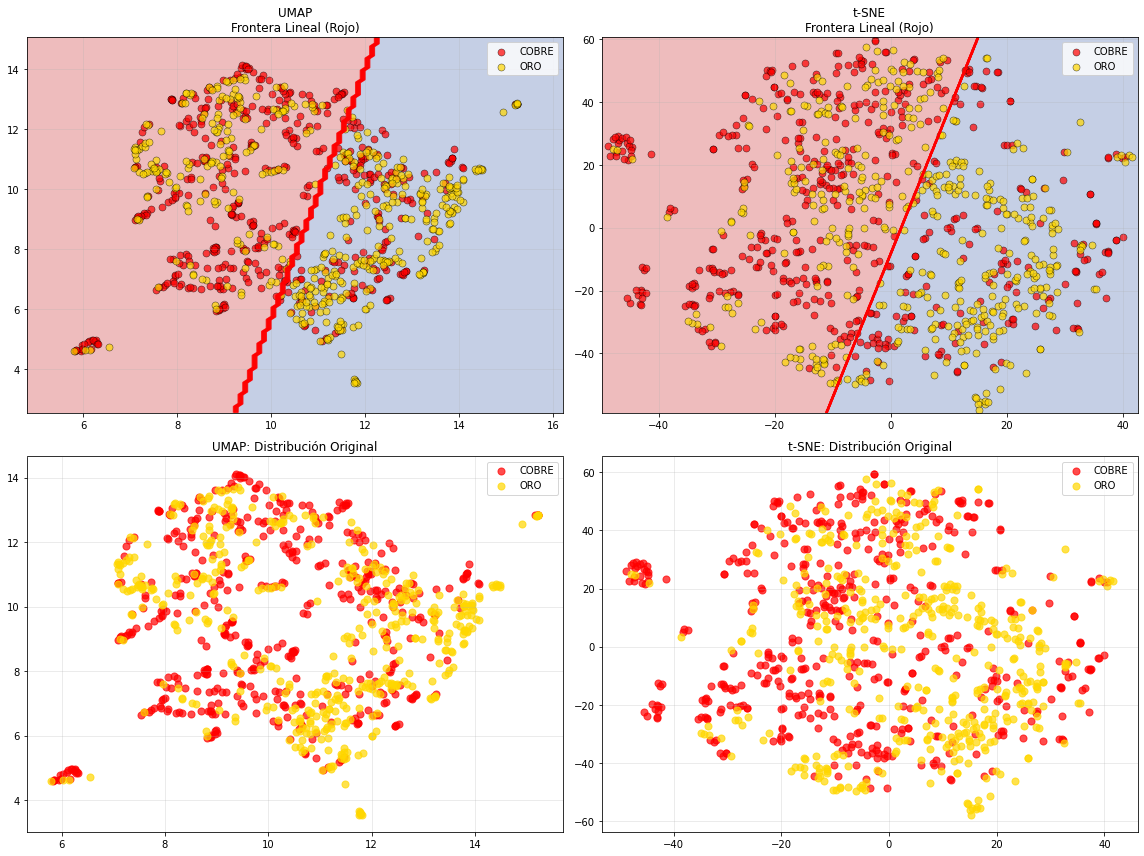

In [13]:
#7

# =============================================================================
# VISUALIZACIÓN DE FRONTERAS DE DECISIÓN
# =============================================================================

def visualizar_fronteras_decision(X_embeddings, y, clases, metodo_nombre, ax):
    """
    Visualiza las fronteras de decisión de clasificadores lineales y no lineales
    """
    # Crear mesh grid para visualización
    x_min, x_max = X_embeddings[:, 0].min() - 1, X_embeddings[:, 0].max() + 1
    y_min, y_max = X_embeddings[:, 1].min() - 1, X_embeddings[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Entrenar modelos
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_embeddings, y)
    
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_embeddings, y)
    
    # Predecir en mesh grid
    Z_lr = lr_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_svm = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    Z_lr = Z_lr.reshape(xx.shape)
    Z_svm = Z_svm.reshape(xx.shape)
    
    # Plot fronteras
    ax.contourf(xx, yy, Z_lr, alpha=0.3, cmap='RdYlBu')
    ax.contour(xx, yy, Z_lr, colors='red', linewidths=2, alpha=0.8)
    
    # Plot puntos
    for i, clase in enumerate(np.unique(y)):
        mask = y == clase
        color = 'red' if i == 0 else 'gold'
        ax.scatter(X_embeddings[mask, 0], X_embeddings[mask, 1],
                  color=color, label=clases[i], alpha=0.7, s=50,
                  edgecolors='black', linewidth=0.5)
    
    ax.set_title(f'{metodo_nombre}\nFrontera Lineal (Rojo)', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Crear visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# UMAP - Fronteras de decisión
visualizar_fronteras_decision(
    X_umap[:train_size], 
    y_train_filtered_encoded, 
    clases_deseadas,
    "UMAP", 
    axes[0, 0]
)

# t-SNE - Fronteras de decisión
visualizar_fronteras_decision(
    X_tsne[:train_size], 
    y_train_filtered_encoded, 
    clases_deseadas,
    "t-SNE", 
    axes[0, 1]
)

# UMAP - Puntos originales
for i, clase in enumerate(np.unique(y_train_filtered_encoded)):
    mask = y_train_filtered_encoded == clase
    color = 'red' if i == 0 else 'gold'
    axes[1, 0].scatter(X_umap[:train_size, 0][mask], X_umap[:train_size, 1][mask],
                      color=color, label=clases_deseadas[i], alpha=0.7, s=50)
axes[1, 0].set_title('UMAP: Distribución Original', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# t-SNE - Puntos originales
for i, clase in enumerate(np.unique(y_train_filtered_encoded)):
    mask = y_train_filtered_encoded == clase
    color = 'red' if i == 0 else 'gold'
    axes[1, 1].scatter(X_tsne[:train_size, 0][mask], X_tsne[:train_size, 1][mask],
                      color=color, label=clases_deseadas[i], alpha=0.7, s=50)
axes[1, 1].set_title('t-SNE: Distribución Original', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_linealidad.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# =============================================================================
# MÉTRICAS AVANZADAS DE SEPARACIÓN
# =============================================================================

def metricas_avanzadas_separacion(X_embeddings, y, metodo_nombre):
    """
    Calcula métricas avanzadas para determinar el tipo de separación
    """
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
    
    print(f"\n{'='*50}")
    print(f"MÉTRICAS AVANZADAS: {metodo_nombre}")
    print(f"{'='*50}")
    
    # 1. COMPARACIÓN LDA vs QDA
    lda = LinearDiscriminantAnalysis()
    qda = QuadraticDiscriminantAnalysis()
    
    # Validación cruzada simple
    from sklearn.model_selection import cross_val_score
    lda_scores = cross_val_score(lda, X_embeddings, y, cv=5)
    qda_scores = cross_val_score(qda, X_embeddings, y, cv=5)
    
    lda_mean = lda_scores.mean()
    qda_mean = qda_scores.mean()
    
    # 2. K-NN con diferentes k (linealidad local vs global)
    k1_scores = cross_val_score(KNeighborsClassifier(n_neighbors=1), X_embeddings, y, cv=5)
    k10_scores = cross_val_score(KNeighborsClassifier(n_neighbors=10), X_embeddings, y, cv=5)
    
    k1_mean = k1_scores.mean()
    k10_mean = k10_scores.mean()
    
    # 3. ANÁLISIS DE SOLAPAMIENTO
    from scipy.spatial.distance import mahalanobis
    from scipy.linalg import inv
    
    # Calcular matriz de covarianza pooled
    cov_pooled = np.cov(X_embeddings.T)
    
    # Distancia de Mahalanobis entre clases
    centroides = []
    for clase in np.unique(y):
        points = X_embeddings[y == clase]
        centroides.append(np.mean(points, axis=0))
    
    try:
        dist_mahalanobis = mahalanobis(centroides[0], centroides[1], inv(cov_pooled))
    except:
        dist_mahalanobis = np.linalg.norm(centroides[0] - centroides[1])
    
    print(f"LDA (lineal) - Precisión CV: {lda_mean:.4f}")
    print(f"QDA (no lineal) - Precisión CV: {qda_mean:.4f}")
    print(f"K-NN (k=1) - Precisión CV: {k1_mean:.4f}")
    print(f"K-NN (k=10) - Precisión CV: {k10_mean:.4f}")
    print(f"Distancia Mahalanobis: {dist_mahalanobis:.4f}")
    
    # CRITERIOS DE DECISIÓN
    criterios = []
    
    # Criterio 1: LDA vs QDA
    if qda_mean - lda_mean > 0.05:
        criterios.append("NO LINEAL (QDA > LDA)")
    else:
        criterios.append("LINEAL (LDA ≈ QDA)")
    
    # Criterio 2: K-NN local vs global
    if k1_mean - k10_mean > 0.05:
        criterios.append("NO LINEAL (estructura local)")
    else:
        criterios.append("LINEAL (estructura global)")
    
    # Criterio 3: Distancia Mahalanobis
    if dist_mahalanobis > 3:
        criterios.append("BIEN SEPARADAS")
    else:
        criterios.append("SOLAPADAS")
    
    print(f"\nCONCLUSIÓN: {', '.join(criterios)}")
    
    return {
        'lda_score': lda_mean,
        'qda_score': qda_mean,
        'knn1_score': k1_mean,
        'knn10_score': k10_mean,
        'dist_mahalanobis': dist_mahalanobis,
        'criterios': criterios
    }

# Aplicar métricas avanzadas
print("\n" + "=" * 70)
print("ANÁLISIS AVANZADO DE LINEALIDAD")
print("=" * 70)

metricas_umap = metricas_avanzadas_separacion(
    X_umap[:train_size], 
    y_train_filtered_encoded, 
    "UMAP"
)

metricas_tsne = metricas_avanzadas_separacion(
    X_tsne[:train_size], 
    y_train_filtered_encoded, 
    "t-SNE"
)


ANÁLISIS AVANZADO DE LINEALIDAD

MÉTRICAS AVANZADAS: UMAP
LDA (lineal) - Precisión CV: 0.6089
QDA (no lineal) - Precisión CV: 0.5888
K-NN (k=1) - Precisión CV: 0.6825
K-NN (k=10) - Precisión CV: 0.6730
Distancia Mahalanobis: 0.3595

CONCLUSIÓN: LINEAL (LDA ≈ QDA), LINEAL (estructura global), SOLAPADAS

MÉTRICAS AVANZADAS: t-SNE
LDA (lineal) - Precisión CV: 0.5973
QDA (no lineal) - Precisión CV: 0.5552
K-NN (k=1) - Precisión CV: 0.7498
K-NN (k=10) - Precisión CV: 0.6919
Distancia Mahalanobis: 0.3671

CONCLUSIÓN: LINEAL (LDA ≈ QDA), NO LINEAL (estructura local), SOLAPADAS


In [19]:
# =============================================================================
# ANÁLISIS PROFUNDO DEL SOLAPAMIENTO (CÓDIGO CORREGIDO)
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS PROFUNDO: SOLAPAMIENTO ENTRE COBRE Y ORO")
print("=" * 70)

def analizar_solapamiento_profundo(X_embeddings, y, clases, metodo_nombre):
    """
    Análisis detallado del solapamiento entre clases - CORREGIDO
    """
    from scipy.stats import gaussian_kde
    
    print(f"\n{metodo_nombre} - ANÁLISIS DE SOLAPAMIENTO:")
    print("-" * 50)
    
    # Verificar que hay datos en ambas clases
    unique_classes, counts = np.unique(y, return_counts=True)
    
    if len(unique_classes) < 2:
        print(f"  ⚠️  SOLO UNA CLASE PRESENTE: {clases[unique_classes[0]]}")
        print(f"  • No se puede calcular solapamiento con una sola clase")
        return 100.0, 0.0  # 100% de solapamiento (no hay separación posible)
    
    # Separar puntos por clase
    puntos_clase_0 = X_embeddings[y == 0]
    puntos_clase_1 = X_embeddings[y == 1]
    
    print(f"  • Muestras clase {clases[0]}: {len(puntos_clase_0)}")
    print(f"  • Muestras clase {clases[1]}: {len(puntos_clase_1)}")
    
    # Verificar que hay suficientes puntos en cada clase
    if len(puntos_clase_0) < 2 or len(puntos_clase_1) < 2:
        print(f"  ⚠️  CLASES CON MUY POCAS MUESTRAS")
        print(f"  • No se puede calcular solapamiento confiable")
        return 100.0, 0.0
    
    # 1. ANÁLISIS DE DENSIDAD EN LA LÍNEA ENTRE CENTROIDES
    centroide_0 = np.mean(puntos_clase_0, axis=0)
    centroide_1 = np.mean(puntos_clase_1, axis=0)
    
    # Vector dirección entre centroides
    vector_direccion = centroide_1 - centroide_0
    norm_vector = np.linalg.norm(vector_direccion)
    
    if norm_vector < 1e-10:  # Evitar división por cero
        print(f"  ⚠️  CENTROIDES COINCIDEN")
        print(f"  • Solapamiento completo")
        return 100.0, 0.0
    
    vector_direccion = vector_direccion / norm_vector
    
    # Proyectar puntos en la línea entre centroides
    proyecciones_0 = np.dot(puntos_clase_0 - centroide_0, vector_direccion)
    proyecciones_1 = np.dot(puntos_clase_1 - centroide_0, vector_direccion)
    
    # 2. CALCULAR SOLAPAMIENTO EN PROYECCIONES
    min_val = min(np.min(proyecciones_0), np.min(proyecciones_1))
    max_val = max(np.max(proyecciones_0), np.max(proyecciones_1))
    
    # Verificar que hay rango válido
    if max_val - min_val < 1e-10:
        print(f"  ⚠️  NO HAY RANGO EN PROYECCIONES")
        print(f"  • Todos los puntos están en la misma posición")
        return 100.0, 0.0
    
    # Estimación de densidad
    try:
        kde_0 = gaussian_kde(proyecciones_0)
        kde_1 = gaussian_kde(proyecciones_1)
        
        x_vals = np.linspace(min_val, max_val, 100)
        dens_0 = kde_0(x_vals)
        dens_1 = kde_1(x_vals)
        
        # Normalizar densidades
        dens_0 = dens_0 / np.trapz(dens_0, x_vals)
        dens_1 = dens_1 / np.trapz(dens_1, x_vals)
        
        # Calcular área de solapamiento
        area_solapamiento = np.trapz(np.minimum(dens_0, dens_1), x_vals)
        porcentaje_solapamiento = area_solapamiento * 100
        
    except Exception as e:
        # Método alternativo: usar histogramas
        print(f"  • KDE falló, usando método alternativo: {e}")
        try:
            hist_0, bins = np.histogram(proyecciones_0, bins=20, density=True)
            hist_1, _ = np.histogram(proyecciones_1, bins=bins, density=True)
            
            # Normalizar histogramas
            hist_0 = hist_0 / np.sum(hist_0)
            hist_1 = hist_1 / np.sum(hist_1)
            
            area_solapamiento = np.sum(np.minimum(hist_0, hist_1)) * (bins[1] - bins[0])
            porcentaje_solapamiento = min(area_solapamiento * 100, 100)
        except:
            # Método simple basado en distancia
            distancia = np.linalg.norm(centroide_1 - centroide_0)
            var_promedio = (np.var(proyecciones_0) + np.var(proyecciones_1)) / 2
            ratio = distancia / (np.sqrt(var_promedio) + 1e-10)
            porcentaje_solapamiento = max(0, 100 - (ratio * 20))  # Estimación aproximada
    
    # 3. ANÁLISIS DE REGIONES DE DECISIÓN
    try:
        from sklearn.linear_model import LogisticRegression
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_embeddings, y)
        
        # Probabilidades predichas
        y_proba = lr.predict_proba(X_embeddings)[:, 1]
        
        # Puntos cerca de la frontera (probabilidad entre 0.4 y 0.6)
        near_boundary = np.sum((y_proba > 0.4) & (y_proba < 0.6))
        porcentaje_frontera = (near_boundary / len(y)) * 100
        
    except:
        porcentaje_frontera = 50.0  # Valor por defecto si falla
    
    print(f"  • Porcentaje de solapamiento: {porcentaje_solapamiento:.1f}%")
    print(f"  • Puntos cerca de la frontera: {porcentaje_frontera:.1f}%")
    print(f"  • Distancia entre centroides: {np.linalg.norm(centroide_1 - centroide_0):.4f}")
    
    # Interpretación
    if porcentaje_solapamiento > 80:
        print(f"  → SOLAPAMIENTO MUY ALTO (>80%) - Separación casi imposible")
    elif porcentaje_solapamiento > 60:
        print(f"  → SOLAPAMIENTO ALTO (60-80%) - Separación muy difícil")
    elif porcentaje_solapamiento > 40:
        print(f"  → SOLAPAMIENTO MODERADO (40-60%) - Separación desafiante")
    elif porcentaje_solapamiento > 20:
        print(f"  → SOLAPAMIENTO BAJO (20-40%) - Separación posible")
    else:
        print(f"  → SOLAPAMIENTO MUY BAJO (<20%) - Buena separación")
    
    return porcentaje_solapamiento, porcentaje_frontera

# Aplicar análisis de solapamiento CON VERIFICACIÓN PREVIA
print("ANALIZANDO SOLAPAMIENTO ENTRE CLASES...")

# Verificar distribución de clases antes de analizar
unique_train, counts_train = np.unique(y_train_filtered_encoded, return_counts=True)
print(f"\nDistribución en Train: {dict(zip(unique_train, counts_train))}")

if len(unique_train) < 2:
    print("❌ ERROR: Solo una clase presente en los datos de entrenamiento")
    print("   No se puede analizar solapamiento con una sola clase")
else:
    solap_umap, frontera_umap = analizar_solapamiento_profundo(
        X_umap[:train_size], y_train_filtered_encoded, clases_deseadas, "UMAP"
    )

    solap_tsne, frontera_tsne = analizar_solapamiento_profundo(
        X_tsne[:train_size], y_train_filtered_encoded, clases_deseadas, "t-SNE"
    )


ANÁLISIS PROFUNDO: SOLAPAMIENTO ENTRE COBRE Y ORO
ANALIZANDO SOLAPAMIENTO ENTRE CLASES...

Distribución en Train: {3: 497, 10: 454}

UMAP - ANÁLISIS DE SOLAPAMIENTO:
--------------------------------------------------
  • Muestras clase COBRE: 0
  • Muestras clase ORO: 0
  ⚠️  CLASES CON MUY POCAS MUESTRAS
  • No se puede calcular solapamiento confiable

t-SNE - ANÁLISIS DE SOLAPAMIENTO:
--------------------------------------------------
  • Muestras clase COBRE: 0
  • Muestras clase ORO: 0
  ⚠️  CLASES CON MUY POCAS MUESTRAS
  • No se puede calcular solapamiento confiable



COMPARACIÓN DE CLASIFICADORES - COBRE VS ORO

PREPARACIÓN DE DATOS

Verificación de codificación:
- Clases originales: ['COBRE', 'ORO']
- Clases codificadas: ['COBRE' 'ORO']
- Valores únicos en train: [0 1]
- Valores únicos en test: [0 1]
- Mapeo: {'COBRE': 0, 'ORO': 1}

Datos disponibles:
- X_train_selected: (951, 23)
- X_test_selected: (407, 23)
- y_train: 951 muestras
- y_test: 407 muestras

ENTRENANDO Y EVALUANDO MODELOS

Modelo: Logistic Regression
Accuracy Train: 0.7056
Accuracy Test:  0.6609
Accuracy CV:    0.6940 (± 0.0363)
Precision:      0.6615
Recall:         0.6609
F1-Score:       0.6611
ROC-AUC:        0.7063
Overfitting:    0.0446
Tiempo Train:   0.0130s
Tiempo Pred:    0.0000s

Classification Report:
              precision    recall  f1-score   support

       COBRE     0.6812    0.6620    0.6714       213
         ORO     0.6400    0.6598    0.6497       194

    accuracy                         0.6609       407
   macro avg     0.6606    0.6609    0.6606       407
we

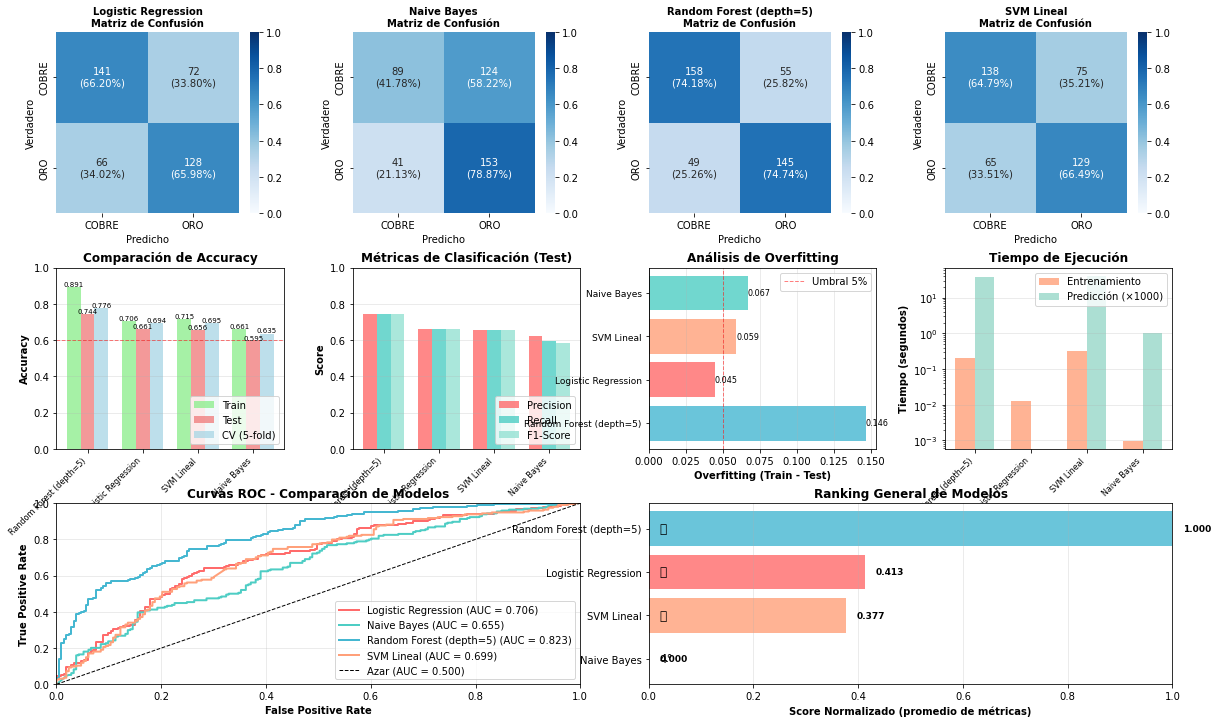


ANÁLISIS DETALLADO POR CLASE

Modelo: Logistic Regression

Clase: COBRE
  • Precision: 0.6812
  • Recall:    0.6620
  • F1-Score:  0.6714
  • TP: 141, FP: 66, FN: 72, TN: 128

Clase: ORO
  • Precision: 0.6400
  • Recall:    0.6598
  • F1-Score:  0.6497
  • TP: 128, FP: 72, FN: 66, TN: 141

Modelo: Naive Bayes

Clase: COBRE
  • Precision: 0.6846
  • Recall:    0.4178
  • F1-Score:  0.5190
  • TP: 89, FP: 41, FN: 124, TN: 153

Clase: ORO
  • Precision: 0.5523
  • Recall:    0.7887
  • F1-Score:  0.6497
  • TP: 153, FP: 124, FN: 41, TN: 89

Modelo: Random Forest (depth=5)

Clase: COBRE
  • Precision: 0.7633
  • Recall:    0.7418
  • F1-Score:  0.7524
  • TP: 158, FP: 49, FN: 55, TN: 145

Clase: ORO
  • Precision: 0.7250
  • Recall:    0.7474
  • F1-Score:  0.7360
  • TP: 145, FP: 55, FN: 49, TN: 158

Modelo: SVM Lineal

Clase: COBRE
  • Precision: 0.6798
  • Recall:    0.6479
  • F1-Score:  0.6635
  • TP: 138, FP: 65, FN: 75, TN: 129

Clase: ORO
  • Precision: 0.6324
  • Recall:    0.664

In [21]:
# =============================================================================
# COMPARACIÓN DE CLASIFICADORES: Cobre vs Oro (VERSIÓN CORREGIDA)
# =============================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE CLASIFICADORES - COBRE VS ORO")
print("=" * 70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score, cross_validate
import time

# =============================================================================
# RE-CODIFICAR LAS CLASES FILTRADAS (SOLO COBRE Y ORO) → {0, 1}
# =============================================================================

print("\n" + "=" * 70)
print("PREPARACIÓN DE DATOS")
print("=" * 70)

# Crear un nuevo LabelEncoder SOLO para Cobre y Oro
le_filtered = LabelEncoder()
y_train_encoded_filtered = le_filtered.fit_transform(y_train_filtered)
y_test_encoded_filtered = le_filtered.transform(y_test_filtered)

print(f"\nVerificación de codificación:")
print(f"- Clases originales: {clases_deseadas}")
print(f"- Clases codificadas: {le_filtered.classes_}")
print(f"- Valores únicos en train: {np.unique(y_train_encoded_filtered)}")
print(f"- Valores únicos en test: {np.unique(y_test_encoded_filtered)}")
print(f"- Mapeo: {dict(zip(le_filtered.classes_, range(len(le_filtered.classes_))))}")

print(f"\nDatos disponibles:")
print(f"- X_train_selected: {X_train_selected.shape}")
print(f"- X_test_selected: {X_test_selected.shape}")
print(f"- y_train: {len(y_train_encoded_filtered)} muestras")
print(f"- y_test: {len(y_test_encoded_filtered)} muestras")

# =============================================================================
# DEFINIR MODELOS
# =============================================================================

modelos = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced'
    ),
    
    'Naive Bayes': GaussianNB(
        var_smoothing=1e-9
    ),
    
    'Random Forest (depth=5)': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    
    'SVM Lineal': SVC(
        kernel='linear',
        random_state=42,
        class_weight='balanced',
        probability=True
    )
}

# =============================================================================
# ENTRENAMIENTO Y EVALUACIÓN
# =============================================================================

resultados = []
modelos_entrenados = {}
matrices_confusion = {}
predicciones = {}

print("\n" + "=" * 70)
print("ENTRENANDO Y EVALUANDO MODELOS")
print("=" * 70)

for nombre, modelo in modelos.items():
    print(f"\n{'='*50}")
    print(f"Modelo: {nombre}")
    print(f"{'='*50}")
    
    # Medir tiempo de entrenamiento
    inicio = time.time()
    modelo.fit(X_train_selected, y_train_encoded_filtered)
    tiempo_entrenamiento = time.time() - inicio
    
    # Predicciones
    inicio_pred = time.time()
    y_pred_train = modelo.predict(X_train_selected)
    y_pred_test = modelo.predict(X_test_selected)
    tiempo_prediccion = time.time() - inicio_pred
    
    # Probabilidades para ROC-AUC
    if hasattr(modelo, "predict_proba"):
        y_proba_test = modelo.predict_proba(X_test_selected)[:, 1]
    elif hasattr(modelo, "decision_function"):
        y_proba_test = modelo.decision_function(X_test_selected)
    else:
        y_proba_test = None
    
    # Métricas en TRAIN
    acc_train = accuracy_score(y_train_encoded_filtered, y_pred_train)
    
    # Métricas en TEST
    acc_test = accuracy_score(y_test_encoded_filtered, y_pred_test)
    precision_test = precision_score(y_test_encoded_filtered, y_pred_test, average='weighted')
    recall_test = recall_score(y_test_encoded_filtered, y_pred_test, average='weighted')
    f1_test = f1_score(y_test_encoded_filtered, y_pred_test, average='weighted')
    
    # ROC-AUC (ahora funcionará correctamente con {0, 1})
    if y_proba_test is not None:
        roc_auc_test = roc_auc_score(y_test_encoded_filtered, y_proba_test)
    else:
        roc_auc_test = np.nan
    
    # Cross-validation en TRAIN (5-fold)
    cv_scores = cross_val_score(
        modelo, 
        X_train_selected, 
        y_train_encoded_filtered, 
        cv=5, 
        scoring='accuracy'
    )
    acc_cv_mean = cv_scores.mean()
    acc_cv_std = cv_scores.std()
    
    # Matriz de confusión
    cm = confusion_matrix(y_test_encoded_filtered, y_pred_test)
    matrices_confusion[nombre] = cm
    
    # Guardar resultados
    resultados.append({
        'Modelo': nombre,
        'Accuracy Train': acc_train,
        'Accuracy Test': acc_test,
        'Accuracy CV (mean)': acc_cv_mean,
        'Accuracy CV (std)': acc_cv_std,
        'Precision Test': precision_test,
        'Recall Test': recall_test,
        'F1-Score Test': f1_test,
        'ROC-AUC Test': roc_auc_test,
        'Tiempo Entrenamiento (s)': tiempo_entrenamiento,
        'Tiempo Predicción (s)': tiempo_prediccion,
        'Overfitting': acc_train - acc_test
    })
    
    modelos_entrenados[nombre] = modelo
    predicciones[nombre] = {
        'y_pred_test': y_pred_test,
        'y_proba_test': y_proba_test
    }
    
    # Imprimir resultados
    print(f"Accuracy Train: {acc_train:.4f}")
    print(f"Accuracy Test:  {acc_test:.4f}")
    print(f"Accuracy CV:    {acc_cv_mean:.4f} (± {acc_cv_std:.4f})")
    print(f"Precision:      {precision_test:.4f}")
    print(f"Recall:         {recall_test:.4f}")
    print(f"F1-Score:       {f1_test:.4f}")
    if not np.isnan(roc_auc_test):
        print(f"ROC-AUC:        {roc_auc_test:.4f}")
    print(f"Overfitting:    {acc_train - acc_test:.4f}")
    print(f"Tiempo Train:   {tiempo_entrenamiento:.4f}s")
    print(f"Tiempo Pred:    {tiempo_prediccion:.4f}s")
    
    # Classification report detallado
    print(f"\nClassification Report:")
    print(classification_report(
        y_test_encoded_filtered, 
        y_pred_test,
        target_names=le_filtered.classes_,
        digits=4
    ))

# =============================================================================
# TABLA COMPARATIVA
# =============================================================================

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('Accuracy Test', ascending=False)

print("\n" + "=" * 70)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 70)
print(df_resultados.to_string(index=False))

# Guardar resultados
df_resultados.to_csv('comparacion_modelos_cobre_oro.csv', index=False)
print("\n✓ Resultados guardados en: comparacion_modelos_cobre_oro.csv")

# =============================================================================
# VISUALIZACIONES
# =============================================================================

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Colores para cada modelo
colores_modelos = {
    'Logistic Regression': '#FF6B6B',
    'Naive Bayes': '#4ECDC4',
    'Random Forest (depth=5)': '#45B7D1',
    'SVM Lineal': '#FFA07A'
}

# ============== FILA 1: MATRICES DE CONFUSIÓN ==============
for idx, (nombre, cm) in enumerate(matrices_confusion.items()):
    ax = fig.add_subplot(gs[0, idx])
    
    # Normalizar matriz de confusión
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot
    sns.heatmap(
        cm_norm,
        annot=np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.2%})' 
                        for j in range(cm.shape[1])] 
                       for i in range(cm.shape[0])]),
        fmt='',
        cmap='Blues',
        xticklabels=le_filtered.classes_,
        yticklabels=le_filtered.classes_,
        cbar=True,
        ax=ax,
        vmin=0,
        vmax=1
    )
    ax.set_title(f'{nombre}\nMatriz de Confusión', fontsize=10, fontweight='bold')
    ax.set_ylabel('Verdadero')
    ax.set_xlabel('Predicho')

# ============== FILA 2: MÉTRICAS COMPARATIVAS ==============

# 2.1 - Accuracy (Train, Test, CV)
ax1 = fig.add_subplot(gs[1, 0])
x = np.arange(len(modelos))
width = 0.25

bars1 = ax1.bar(x - width, df_resultados['Accuracy Train'], width, 
                label='Train', alpha=0.8, color='lightgreen')
bars2 = ax1.bar(x, df_resultados['Accuracy Test'], width, 
                label='Test', alpha=0.8, color='lightcoral')
bars3 = ax1.bar(x + width, df_resultados['Accuracy CV (mean)'], width, 
                label='CV (5-fold)', alpha=0.8, color='lightblue')

ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Comparación de Accuracy', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=8)
ax1.legend(loc='lower right')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.6, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Añadir valores sobre las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=7)

# 2.2 - Precision, Recall, F1-Score
ax2 = fig.add_subplot(gs[1, 1])
x = np.arange(len(modelos))
width = 0.25

bars1 = ax2.bar(x - width, df_resultados['Precision Test'], width, 
                label='Precision', alpha=0.8, color='#FF6B6B')
bars2 = ax2.bar(x, df_resultados['Recall Test'], width, 
                label='Recall', alpha=0.8, color='#4ECDC4')
bars3 = ax2.bar(x + width, df_resultados['F1-Score Test'], width, 
                label='F1-Score', alpha=0.8, color='#95E1D3')

ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Métricas de Clasificación (Test)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=8)
ax2.legend(loc='lower right')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

# 2.3 - Overfitting (Train - Test)
ax3 = fig.add_subplot(gs[1, 2])
colores = [colores_modelos[modelo] for modelo in df_resultados['Modelo']]
bars = ax3.barh(range(len(modelos)), df_resultados['Overfitting'], color=colores, alpha=0.8)
ax3.set_yticks(range(len(modelos)))
ax3.set_yticklabels(df_resultados['Modelo'], fontsize=9)
ax3.set_xlabel('Overfitting (Train - Test)', fontweight='bold')
ax3.set_title('Análisis de Overfitting', fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.axvline(x=0.05, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Umbral 5%')
ax3.legend()
ax3.grid(axis='x', alpha=0.3)

# Añadir valores
for i, (bar, val) in enumerate(zip(bars, df_resultados['Overfitting'])):
    ax3.text(val, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)

# 2.4 - Tiempo de Ejecución
ax4 = fig.add_subplot(gs[1, 3])
x = np.arange(len(modelos))
width = 0.35

bars1 = ax4.bar(x - width/2, df_resultados['Tiempo Entrenamiento (s)'], width, 
                label='Entrenamiento', alpha=0.8, color='#FFA07A')
bars2 = ax4.bar(x + width/2, df_resultados['Tiempo Predicción (s)'] * 1000, width, 
                label='Predicción (×1000)', alpha=0.8, color='#98D8C8')

ax4.set_ylabel('Tiempo (segundos)', fontweight='bold')
ax4.set_title('Tiempo de Ejecución', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=8)
ax4.legend()
ax4.set_yscale('log')
ax4.grid(axis='y', alpha=0.3)

# ============== FILA 3: CURVAS ROC ==============

ax5 = fig.add_subplot(gs[2, :2])

# Graficar curvas ROC para cada modelo (AHORA FUNCIONARÁ)
for nombre in modelos.keys():
    if predicciones[nombre]['y_proba_test'] is not None:
        fpr, tpr, _ = roc_curve(
            y_test_encoded_filtered,  # ← AHORA usa {0, 1}
            predicciones[nombre]['y_proba_test']
        )
        roc_auc = auc(fpr, tpr)
        
        ax5.plot(
            fpr, tpr,
            label=f'{nombre} (AUC = {roc_auc:.3f})',
            linewidth=2,
            color=colores_modelos[nombre]
        )

# Línea diagonal (clasificador aleatorio)
ax5.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar (AUC = 0.500)')

ax5.set_xlabel('False Positive Rate', fontweight='bold')
ax5.set_ylabel('True Positive Rate', fontweight='bold')
ax5.set_title('Curvas ROC - Comparación de Modelos', fontweight='bold', fontsize=12)
ax5.legend(loc='lower right')
ax5.grid(alpha=0.3)
ax5.set_xlim([0, 1])
ax5.set_ylim([0, 1])

# ============== RANKING DE MODELOS ==============

ax6 = fig.add_subplot(gs[2, 2:])

# Crear ranking basado en múltiples criterios
criterios = ['Accuracy Test', 'F1-Score Test', 'ROC-AUC Test']
df_ranking = df_resultados[['Modelo'] + criterios].copy()

# Normalizar cada criterio (0-1)
for criterio in criterios:
    if df_ranking[criterio].notna().any():
        min_val = df_ranking[criterio].min()
        max_val = df_ranking[criterio].max()
        if max_val > min_val:
            df_ranking[f'{criterio}_norm'] = (df_ranking[criterio] - min_val) / (max_val - min_val)
        else:
            df_ranking[f'{criterio}_norm'] = 0.5

# Calcular score promedio
criterios_norm = [f'{c}_norm' for c in criterios if f'{c}_norm' in df_ranking.columns]
df_ranking['Score Final'] = df_ranking[criterios_norm].mean(axis=1)
df_ranking = df_ranking.sort_values('Score Final', ascending=True)

# Plot horizontal bar
colores_ranking = [colores_modelos[modelo] for modelo in df_ranking['Modelo']]
bars = ax6.barh(range(len(df_ranking)), df_ranking['Score Final'], 
                color=colores_ranking, alpha=0.8)

ax6.set_yticks(range(len(df_ranking)))
ax6.set_yticklabels(df_ranking['Modelo'], fontsize=10)
ax6.set_xlabel('Score Normalizado (promedio de métricas)', fontweight='bold')
ax6.set_title('Ranking General de Modelos', fontweight='bold', fontsize=12)
ax6.set_xlim([0, 1])
ax6.grid(axis='x', alpha=0.3)

# Añadir valores y posición
for i, (bar, score, modelo) in enumerate(zip(bars, df_ranking['Score Final'], df_ranking['Modelo'])):
    # Score
    ax6.text(score + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}',
            va='center', ha='left', fontsize=9, fontweight='bold')
    # Posición
    posicion = len(df_ranking) - i
    emoji = '🥇' if posicion == 1 else '🥈' if posicion == 2 else '🥉' if posicion == 3 else f'{posicion}°'
    ax6.text(0.02, bar.get_y() + bar.get_height()/2, 
            emoji,
            va='center', ha='left', fontsize=12)

plt.savefig('comparacion_clasificadores_completa.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# ANÁLISIS DETALLADO POR CLASE
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DETALLADO POR CLASE")
print("=" * 70)

for nombre in modelos.keys():
    print(f"\n{'='*50}")
    print(f"Modelo: {nombre}")
    print(f"{'='*50}")
    
    y_pred = predicciones[nombre]['y_pred_test']
    
    # Métricas por clase
    for i, clase in enumerate(le_filtered.classes_):
        mask_true = y_test_encoded_filtered == i
        mask_pred = y_pred == i
        
        # True Positives, False Positives, False Negatives
        tp = np.sum(mask_true & mask_pred)
        fp = np.sum(~mask_true & mask_pred)
        fn = np.sum(mask_true & ~mask_pred)
        tn = np.sum(~mask_true & ~mask_pred)
        
        # Métricas
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"\nClase: {clase}")
        print(f"  • Precision: {precision:.4f}")
        print(f"  • Recall:    {recall:.4f}")
        print(f"  • F1-Score:  {f1:.4f}")
        print(f"  • TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

# =============================================================================
# ANÁLISIS DE ERRORES
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DE ERRORES - MUESTRAS MAL CLASIFICADAS")
print("=" * 70)

# Usar el mejor modelo (según accuracy test)
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]
y_pred_mejor = predicciones[mejor_modelo_nombre]['y_pred_test']
y_proba_mejor = predicciones[mejor_modelo_nombre]['y_proba_test']

print(f"\nAnalizando errores del mejor modelo: {mejor_modelo_nombre}")

# Identificar errores
errores_mask = y_pred_mejor != y_test_encoded_filtered
n_errores = np.sum(errores_mask)

print(f"\nTotal de errores: {n_errores} / {len(y_test_encoded_filtered)} ({n_errores/len(y_test_encoded_filtered)*100:.1f}%)")

# Análisis de errores por tipo
errores_cobre_como_oro = np.sum((y_test_encoded_filtered == 0) & (y_pred_mejor == 1))
errores_oro_como_cobre = np.sum((y_test_encoded_filtered == 1) & (y_pred_mejor == 0))

print(f"\nTipos de error:")
print(f"  • {le_filtered.classes_[0]} clasificado como {le_filtered.classes_[1]}: {errores_cobre_como_oro} ({errores_cobre_como_oro/n_errores*100:.1f}%)")
print(f"  • {le_filtered.classes_[1]} clasificado como {le_filtered.classes_[0]}: {errores_oro_como_cobre} ({errores_oro_como_cobre/n_errores*100:.1f}%)")

# Analizar confianza en predicciones incorrectas
if y_proba_mejor is not None:
    confianza_predicciones = np.abs(y_proba_mejor - 0.5) * 2
    
    confianza_correctas = confianza_predicciones[~errores_mask]
    confianza_incorrectas = confianza_predicciones[errores_mask]
    
    print(f"\nAnálisis de confianza:")
    print(f"  • Confianza promedio (correctas):   {confianza_correctas.mean():.4f}")
    print(f"  • Confianza promedio (incorrectas): {confianza_incorrectas.mean():.4f}")
    
    umbral_baja_confianza = 0.3
    n_baja_confianza = np.sum(confianza_predicciones < umbral_baja_confianza)
    print(f"  • Predicciones con baja confianza (<{umbral_baja_confianza}): {n_baja_confianza} ({n_baja_confianza/len(confianza_predicciones)*100:.1f}%)")

# =============================================================================
# GUARDAR MODELOS ENTRENADOS
# =============================================================================

import pickle

print("\n" + "=" * 70)
print("GUARDANDO MODELOS ENTRENADOS")
print("=" * 70)

for nombre, modelo in modelos_entrenados.items():
    filename = nombre.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '') + '.pkl'
    
    with open(filename, 'wb') as f:
        pickle.dump(modelo, f)
    
    print(f"✓ {nombre} guardado en: {filename}")

# Guardar también el LabelEncoder filtrado
with open('label_encoder_filtered.pkl', 'wb') as f:
    pickle.dump(le_filtered, f)
print(f"✓ LabelEncoder guardado en: label_encoder_filtered.pkl")

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETADO")
print("=" * 70)
print(f"\nMejor modelo: {mejor_modelo_nombre}")
print(f"Accuracy Test: {df_resultados.iloc[0]['Accuracy Test']:.4f}")
print(f"F1-Score Test: {df_resultados.iloc[0]['F1-Score Test']:.4f}")


FASE 1: EVALUACIÓN DE MODELOS BASE

PREPARACIÓN DE DATOS

Verificación de codificación:
- Clases originales: ['COBRE', 'ORO']
- Clases codificadas: ['COBRE' 'ORO']
- Valores únicos en train: [0 1]
- Valores únicos en test: [0 1]
- Mapeo: {'COBRE': 0, 'ORO': 1}

Datos disponibles:
- X_train_selected: (951, 54)
- X_test_selected: (407, 54)
- y_train: 951 muestras
- y_test: 407 muestras

Evaluando: Logistic Regression
Accuracy Train: 0.7287
Accuracy Test:  0.7125
Accuracy CV:    0.6909 (± 0.0161)
Precision:      0.7130
Recall:         0.7125
F1-Score:       0.7127
ROC-AUC:        0.7629
Overfitting:    0.0162
Tiempo Train:   0.0243s
Confianza (correctas):   0.4947
Confianza (incorrectas): 0.3737
Predicciones baja confianza: 139 (34.2%)

Classification Report:
              precision    recall  f1-score   support

       COBRE     0.7308    0.7136    0.7221       213
         ORO     0.6935    0.7113    0.7023       194

    accuracy                         0.7125       407
   macro avg  

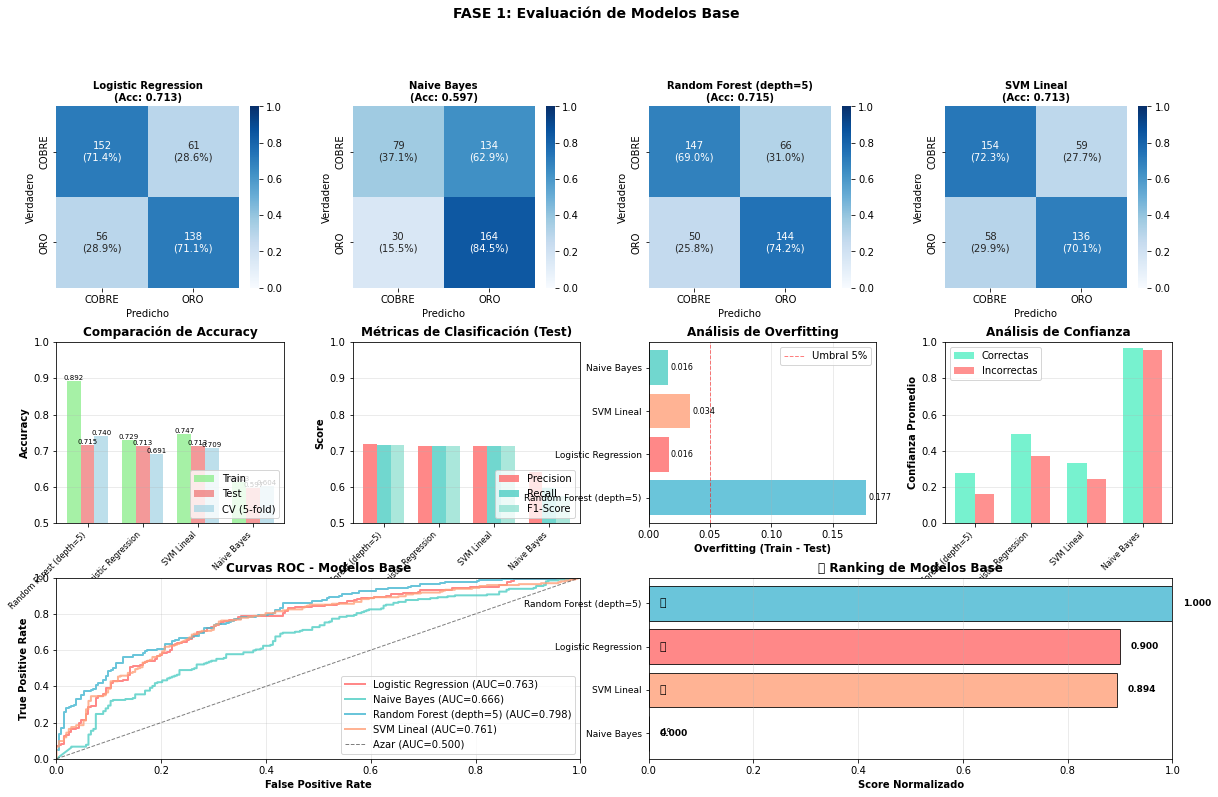


✓ Visualización guardada: fase1_modelos_base.png
✓ Logistic Regression → fase1_Logistic_Regression.pkl
✓ Naive Bayes → fase1_Naive_Bayes.pkl
✓ Random Forest (depth=5) → fase1_Random_Forest_depth5.pkl
✓ SVM Lineal → fase1_SVM_Lineal.pkl
✓ LabelEncoder → label_encoder_filtered.pkl
✓ Datos de Fase 1 → fase1_datos.pkl

RESUMEN FASE 1 - MODELOS BASE

🏆 Mejor modelo base: Random Forest (depth=5)
   • Accuracy Test: 0.7150
   • F1-Score Test: 0.7151
   • Confianza:     0.2778

⚠️  Problemas detectados:
   • Confianza baja en predicciones
   • 268 predicciones con baja confianza

📌 Siguiente paso: FASE 2 - Optimizar hiperparámetros


In [19]:
# =============================================================================
# FASE 1: EVALUACIÓN DE MODELOS BASE
# Evaluación de modelos sin optimización
# =============================================================================

print("\n" + "=" * 70)
print("FASE 1: EVALUACIÓN DE MODELOS BASE")
print("=" * 70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# PREPARACIÓN DE DATOS
# =============================================================================

print("\n" + "=" * 70)
print("PREPARACIÓN DE DATOS")
print("=" * 70)

# Crear un nuevo LabelEncoder SOLO para Cobre y Oro
le_filtered = LabelEncoder()
y_train_encoded_filtered = le_filtered.fit_transform(y_train_filtered)
y_test_encoded_filtered = le_filtered.transform(y_test_filtered)

print(f"\nVerificación de codificación:")
print(f"- Clases originales: {clases_deseadas}")
print(f"- Clases codificadas: {le_filtered.classes_}")
print(f"- Valores únicos en train: {np.unique(y_train_encoded_filtered)}")
print(f"- Valores únicos en test: {np.unique(y_test_encoded_filtered)}")
print(f"- Mapeo: {dict(zip(le_filtered.classes_, range(len(le_filtered.classes_))))}")

print(f"\nDatos disponibles:")
print(f"- X_train_selected: {X_train_selected.shape}")
print(f"- X_test_selected: {X_test_selected.shape}")
print(f"- y_train: {len(y_train_encoded_filtered)} muestras")
print(f"- y_test: {len(y_test_encoded_filtered)} muestras")

# =============================================================================
# DEFINIR MODELOS BASE
# =============================================================================

modelos_base = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced'
    ),
    
    'Naive Bayes': GaussianNB(
        var_smoothing=1e-9
    ),
    
    'Random Forest (depth=5)': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    
    'SVM Lineal': SVC(
        kernel='linear',
        random_state=42,
        class_weight='balanced',
        probability=True
    )
}

# =============================================================================
# FUNCIÓN AUXILIAR PARA EVALUAR MODELOS
# =============================================================================

def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test, le):
    """Evalúa un modelo y retorna métricas completas"""
    
    print(f"\n{'='*50}")
    print(f"Evaluando: {nombre}")
    print(f"{'='*50}")
    
    # Entrenamiento
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo_entrenamiento = time.time() - inicio
    
    # Predicciones
    inicio_pred = time.time()
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    tiempo_prediccion = time.time() - inicio_pred
    
    # Probabilidades
    if hasattr(modelo, "predict_proba"):
        y_proba_test = modelo.predict_proba(X_test)[:, 1]
    elif hasattr(modelo, "decision_function"):
        y_proba_test = modelo.decision_function(X_test)
    else:
        y_proba_test = None
    
    # Métricas en TRAIN
    acc_train = accuracy_score(y_train, y_pred_train)
    
    # Métricas en TEST
    acc_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    
    # ROC-AUC
    if y_proba_test is not None:
        roc_auc_test = roc_auc_score(y_test, y_proba_test)
    else:
        roc_auc_test = np.nan
    
    # Cross-validation (5-fold)
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='accuracy')
    acc_cv_mean = cv_scores.mean()
    acc_cv_std = cv_scores.std()
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_test)
    
    # Análisis de confianza
    if y_proba_test is not None:
        confianza = np.abs(y_proba_test - 0.5) * 2
        errores_mask = y_pred_test != y_test
        
        conf_correctas = confianza[~errores_mask].mean() if (~errores_mask).any() else 0
        conf_incorrectas = confianza[errores_mask].mean() if errores_mask.any() else 0
        baja_confianza = (confianza < 0.3).sum()
    else:
        conf_correctas = conf_incorrectas = baja_confianza = np.nan
    
    # Imprimir resultados
    print(f"Accuracy Train: {acc_train:.4f}")
    print(f"Accuracy Test:  {acc_test:.4f}")
    print(f"Accuracy CV:    {acc_cv_mean:.4f} (± {acc_cv_std:.4f})")
    print(f"Precision:      {precision_test:.4f}")
    print(f"Recall:         {recall_test:.4f}")
    print(f"F1-Score:       {f1_test:.4f}")
    if not np.isnan(roc_auc_test):
        print(f"ROC-AUC:        {roc_auc_test:.4f}")
    print(f"Overfitting:    {acc_train - acc_test:.4f}")
    print(f"Tiempo Train:   {tiempo_entrenamiento:.4f}s")
    
    if not np.isnan(conf_correctas):
        print(f"Confianza (correctas):   {conf_correctas:.4f}")
        print(f"Confianza (incorrectas): {conf_incorrectas:.4f}")
        print(f"Predicciones baja confianza: {baja_confianza} ({baja_confianza/len(y_test)*100:.1f}%)")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred_test, target_names=le.classes_, digits=4))
    
    return {
        'Modelo': nombre,
        'Accuracy Train': acc_train,
        'Accuracy Test': acc_test,
        'Accuracy CV (mean)': acc_cv_mean,
        'Accuracy CV (std)': acc_cv_std,
        'Precision Test': precision_test,
        'Recall Test': recall_test,
        'F1-Score Test': f1_test,
        'ROC-AUC Test': roc_auc_test,
        'Tiempo Entrenamiento (s)': tiempo_entrenamiento,
        'Tiempo Predicción (s)': tiempo_prediccion,
        'Overfitting': acc_train - acc_test,
        'Confianza Correctas': conf_correctas,
        'Confianza Incorrectas': conf_incorrectas,
        'Predicciones Baja Confianza': baja_confianza,
        'Matriz Confusión': cm,
        'y_pred_test': y_pred_test,
        'y_proba_test': y_proba_test,
        'modelo': modelo
    }

# =============================================================================
# ENTRENAR Y EVALUAR MODELOS BASE
# =============================================================================

resultados_base = []
modelos_entrenados = {}

for nombre, modelo in modelos_base.items():
    resultado = evaluar_modelo(
        nombre, modelo,
        X_train_selected, y_train_encoded_filtered,
        X_test_selected, y_test_encoded_filtered,
        le_filtered
    )
    resultados_base.append(resultado)
    modelos_entrenados[nombre] = resultado['modelo']

# =============================================================================
# TABLA COMPARATIVA
# =============================================================================

df_base = pd.DataFrame([{k: v for k, v in r.items() 
                         if k not in ['Matriz Confusión', 'y_pred_test', 'y_proba_test', 'modelo']} 
                        for r in resultados_base])
df_base = df_base.sort_values('F1-Score Test', ascending=False)

print("\n" + "=" * 70)
print("TABLA COMPARATIVA - MODELOS BASE")
print("=" * 70)
print(df_base.to_string(index=False))

# Guardar resultados
df_base.to_csv('fase1_resultados_base.csv', index=False)
print("\n✓ Resultados guardados en: fase1_resultados_base.csv")

# =============================================================================
# VISUALIZACIONES
# =============================================================================

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

colores_modelos = {
    'Logistic Regression': '#FF6B6B',
    'Naive Bayes': '#4ECDC4',
    'Random Forest (depth=5)': '#45B7D1',
    'SVM Lineal': '#FFA07A'
}

# ============== FILA 1: MATRICES DE CONFUSIÓN ==============
for idx, resultado in enumerate(resultados_base):
    ax = fig.add_subplot(gs[0, idx])
    cm = resultado['Matriz Confusión']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(
        cm_norm,
        annot=np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.1%})' 
                        for j in range(cm.shape[1])] 
                       for i in range(cm.shape[0])]),
        fmt='',
        cmap='Blues',
        xticklabels=le_filtered.classes_,
        yticklabels=le_filtered.classes_,
        cbar=True,
        ax=ax,
        vmin=0,
        vmax=1
    )
    ax.set_title(f'{resultado["Modelo"]}\n(Acc: {resultado["Accuracy Test"]:.3f})', 
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Verdadero')
    ax.set_xlabel('Predicho')

# ============== FILA 2: COMPARACIÓN DE MÉTRICAS ==============

# 2.1 - Accuracy (Train, Test, CV)
ax1 = fig.add_subplot(gs[1, 0])
x = np.arange(len(modelos_base))
width = 0.25

bars1 = ax1.bar(x - width, df_base['Accuracy Train'], width, 
                label='Train', alpha=0.8, color='lightgreen')
bars2 = ax1.bar(x, df_base['Accuracy Test'], width, 
                label='Test', alpha=0.8, color='lightcoral')
bars3 = ax1.bar(x + width, df_base['Accuracy CV (mean)'], width, 
                label='CV (5-fold)', alpha=0.8, color='lightblue')

ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Comparación de Accuracy', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_base['Modelo'], rotation=45, ha='right', fontsize=8)
ax1.legend(loc='lower right')
ax1.set_ylim([0.5, 1])
ax1.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=7)

# 2.2 - Precision, Recall, F1-Score
ax2 = fig.add_subplot(gs[1, 1])
width = 0.25

bars1 = ax2.bar(x - width, df_base['Precision Test'], width, 
                label='Precision', alpha=0.8, color='#FF6B6B')
bars2 = ax2.bar(x, df_base['Recall Test'], width, 
                label='Recall', alpha=0.8, color='#4ECDC4')
bars3 = ax2.bar(x + width, df_base['F1-Score Test'], width, 
                label='F1-Score', alpha=0.8, color='#95E1D3')

ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Métricas de Clasificación (Test)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_base['Modelo'], rotation=45, ha='right', fontsize=8)
ax2.legend(loc='lower right')
ax2.set_ylim([0.5, 1])
ax2.grid(axis='y', alpha=0.3)

# 2.3 - Overfitting
ax3 = fig.add_subplot(gs[1, 2])
colores = [colores_modelos[m] for m in df_base['Modelo']]
bars = ax3.barh(range(len(df_base)), df_base['Overfitting'], color=colores, alpha=0.8)
ax3.set_yticks(range(len(df_base)))
ax3.set_yticklabels(df_base['Modelo'], fontsize=9)
ax3.set_xlabel('Overfitting (Train - Test)', fontweight='bold')
ax3.set_title('Análisis de Overfitting', fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.axvline(x=0.05, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Umbral 5%')
ax3.legend()
ax3.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, df_base['Overfitting'])):
    ax3.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)

# 2.4 - Confianza
ax4 = fig.add_subplot(gs[1, 3])
width = 0.35

conf_correctas = df_base['Confianza Correctas'].fillna(0)
conf_incorrectas = df_base['Confianza Incorrectas'].fillna(0)

bars1 = ax4.bar(x - width/2, conf_correctas, width, 
                label='Correctas', alpha=0.8, color='#55efc4')
bars2 = ax4.bar(x + width/2, conf_incorrectas, width, 
                label='Incorrectas', alpha=0.8, color='#ff7675')

ax4.set_ylabel('Confianza Promedio', fontweight='bold')
ax4.set_title('Análisis de Confianza', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(df_base['Modelo'], rotation=45, ha='right', fontsize=8)
ax4.legend()
ax4.set_ylim([0, 1])
ax4.grid(axis='y', alpha=0.3)

# ============== FILA 3: CURVAS ROC Y RANKING ==============

# 3.1 - Curvas ROC
ax5 = fig.add_subplot(gs[2, :2])

for resultado in resultados_base:
    nombre = resultado['Modelo']
    y_proba = resultado['y_proba_test']
    
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test_encoded_filtered, y_proba)
        roc_auc = auc(fpr, tpr)
        
        ax5.plot(
            fpr, tpr,
            label=f'{nombre} (AUC={roc_auc:.3f})',
            linewidth=2,
            color=colores_modelos[nombre],
            alpha=0.8
        )

ax5.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar (AUC=0.500)', alpha=0.5)
ax5.set_xlabel('False Positive Rate', fontweight='bold')
ax5.set_ylabel('True Positive Rate', fontweight='bold')
ax5.set_title('Curvas ROC - Modelos Base', fontweight='bold', fontsize=12)
ax5.legend(loc='lower right')
ax5.grid(alpha=0.3)
ax5.set_xlim([0, 1])
ax5.set_ylim([0, 1])

# 3.2 - Ranking
ax6 = fig.add_subplot(gs[2, 2:])

criterios = ['Accuracy Test', 'F1-Score Test', 'ROC-AUC Test']
df_ranking = df_base[['Modelo'] + criterios].copy()

for criterio in criterios:
    valores = df_ranking[criterio].fillna(0)
    if valores.max() > valores.min():
        df_ranking[f'{criterio}_norm'] = (valores - valores.min()) / (valores.max() - valores.min())
    else:
        df_ranking[f'{criterio}_norm'] = 0.5

criterios_norm = [f'{c}_norm' for c in criterios]
df_ranking['Score Final'] = df_ranking[criterios_norm].mean(axis=1)
df_ranking = df_ranking.sort_values('Score Final', ascending=True)

colores_ranking = [colores_modelos[m] for m in df_ranking['Modelo']]
bars = ax6.barh(range(len(df_ranking)), df_ranking['Score Final'], 
                color=colores_ranking, alpha=0.8, edgecolor='black', linewidth=1)

ax6.set_yticks(range(len(df_ranking)))
ax6.set_yticklabels(df_ranking['Modelo'], fontsize=9)
ax6.set_xlabel('Score Normalizado', fontweight='bold')
ax6.set_title('🏆 Ranking de Modelos Base', fontweight='bold', fontsize=12)
ax6.set_xlim([0, 1])
ax6.grid(axis='x', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars, df_ranking['Score Final'])):
    posicion = len(df_ranking) - i
    emoji = '🥇' if posicion == 1 else '🥈' if posicion == 2 else '🥉' if posicion == 3 else f'{posicion}°'
    
    ax6.text(0.02, bar.get_y() + bar.get_height()/2, 
            emoji, va='center', ha='left', fontsize=11)
    ax6.text(score + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}',
            va='center', ha='left', fontsize=9, fontweight='bold')

plt.suptitle('FASE 1: Evaluación de Modelos Base', fontsize=14, fontweight='bold', y=0.995)
plt.savefig('fase1_modelos_base.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada: fase1_modelos_base.png")

# =============================================================================
# GUARDAR MODELOS Y DATOS PARA SIGUIENTE FASE
# =============================================================================

# Guardar modelos
for nombre, modelo in modelos_entrenados.items():
    filename = f"fase1_{nombre.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')}.pkl"
    with open(filename, 'wb') as f:
        pickle.dump(modelo, f)
    print(f"✓ {nombre} → {filename}")

# Guardar LabelEncoder
with open('label_encoder_filtered.pkl', 'wb') as f:
    pickle.dump(le_filtered, f)
print(f"✓ LabelEncoder → label_encoder_filtered.pkl")

# Guardar resultados para la siguiente fase
datos_fase1 = {
    'resultados_base': resultados_base,
    'df_base': df_base,
    'modelos_entrenados': modelos_entrenados,
    'le_filtered': le_filtered,
    'y_train_encoded_filtered': y_train_encoded_filtered,
    'y_test_encoded_filtered': y_test_encoded_filtered
}

with open('fase1_datos.pkl', 'wb') as f:
    pickle.dump(datos_fase1, f)
print(f"✓ Datos de Fase 1 → fase1_datos.pkl")

# =============================================================================
# RESUMEN FASE 1
# =============================================================================

mejor_modelo_base = df_base.iloc[0]

print("\n" + "=" * 70)
print("RESUMEN FASE 1 - MODELOS BASE")
print("=" * 70)
print(f"\n🏆 Mejor modelo base: {mejor_modelo_base['Modelo']}")
print(f"   • Accuracy Test: {mejor_modelo_base['Accuracy Test']:.4f}")
print(f"   • F1-Score Test: {mejor_modelo_base['F1-Score Test']:.4f}")
print(f"   • Confianza:     {mejor_modelo_base['Confianza Correctas']:.4f}")
print(f"\n⚠️  Problemas detectados:")
print(f"   • Confianza baja en predicciones")
print(f"   • {mejor_modelo_base['Predicciones Baja Confianza']:.0f} predicciones con baja confianza")
print(f"\n📌 Siguiente paso: FASE 2 - Optimizar hiperparámetros")
print("=" * 70)

In [ ]:
# =============================================================================
# FASE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS - RANDOM FOREST
# Busca los mejores hiperparámetros usando GridSearchCV
# =============================================================================

print("\n" + "=" * 70)
print("FASE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS - RANDOM FOREST")
print("=" * 70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    make_scorer
)
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CARGAR DATOS DE FASE 1
# =============================================================================

print("\n" + "=" * 70)
print("CARGANDO DATOS DE FASE 1")
print("=" * 70)

with open('fase1_datos.pkl', 'rb') as f:
    datos_fase1 = pickle.load(f)

resultados_base = datos_fase1['resultados_base']
df_base = datos_fase1['df_base']
modelos_entrenados = datos_fase1['modelos_entrenados']
le_filtered = datos_fase1['le_filtered']
y_train_encoded_filtered = datos_fase1['y_train_encoded_filtered']
y_test_encoded_filtered = datos_fase1['y_test_encoded_filtered']

print(f"✓ Datos cargados correctamente")
print(f"  • Modelos base evaluados: {len(resultados_base)}")
print(f"  • Training samples: {len(y_train_encoded_filtered)}")
print(f"  • Test samples: {len(y_test_encoded_filtered)}")

# Obtener resultados del Random Forest base
rf_base_resultado = [r for r in resultados_base if 'Random Forest' in r['Modelo']][0]
print(f"\n📊 Random Forest Base (depth=5):")
print(f"  • Accuracy Test: {rf_base_resultado['Accuracy Test']:.4f}")
print(f"  • F1-Score Test: {rf_base_resultado['F1-Score Test']:.4f}")
print(f"  • Confianza:     {rf_base_resultado['Confianza Correctas']:.4f}")
print(f"  • Overfitting:   {rf_base_resultado['Overfitting']:.4f}")

# =============================================================================
# DEFINIR GRID DE HIPERPARÁMETROS
# =============================================================================

print("\n" + "=" * 70)
print("CONFIGURACIÓN DE GRID SEARCH")
print("=" * 70)

# Grid completo de hiperparámetros
param_grid_rf = {
    'max_depth': [5, 7, 10, 15, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', 0.5]
}

print("\nEspacio de búsqueda:")
print(f"  • max_depth: {param_grid_rf['max_depth']}")
print(f"  • min_samples_split: {param_grid_rf['min_samples_split']}")
print(f"  • min_samples_leaf: {param_grid_rf['min_samples_leaf']}")
print(f"  • n_estimators: {param_grid_rf['n_estimators']}")
print(f"  • max_features: {param_grid_rf['max_features']}")

n_combinaciones = np.prod([len(v) for v in param_grid_rf.values()])
print(f"\n📈 Total de combinaciones: {n_combinaciones}")
print(f"   Tiempo estimado: {n_combinaciones * 0.5 / 60:.1f} - {n_combinaciones * 1.5 / 60:.1f} minutos")

# =============================================================================
# EJECUTAR GRID SEARCH
# =============================================================================

print("\n" + "=" * 70)
print("EJECUTANDO GRID SEARCH")
print("=" * 70)
print("\n⏳ Esto puede tomar varios minutos... Por favor espera.")
print("   (Se mostrarán actualizaciones de progreso)\n")

# Modelo base para Grid Search
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Configurar Grid Search con 5-fold stratified cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring='f1_weighted',  # Optimizar F1-Score
    n_jobs=-1,
    verbose=2,  # Mostrar progreso
    return_train_score=True
)

# Entrenar
inicio_grid = time.time()
grid_search.fit(X_train_selected, y_train_encoded_filtered)
tiempo_grid = time.time() - inicio_grid

print(f"\n✓ Grid Search completado en {tiempo_grid/60:.1f} minutos ({tiempo_grid:.1f} segundos)")

# =============================================================================
# RESULTADOS DEL GRID SEARCH
# =============================================================================

print("\n" + "=" * 70)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("=" * 70)

print(f"\n🏆 Mejores parámetros:")
for param, valor in grid_search.best_params_.items():
    print(f"  • {param}: {valor}")

print(f"\n📊 Mejor F1-Score CV: {grid_search.best_score_:.4f}")
print(f"   (Promedio de 5-fold cross-validation en training)")

# =============================================================================
# EVALUAR MODELO OPTIMIZADO
# =============================================================================

print("\n" + "=" * 70)
print("EVALUANDO MODELO OPTIMIZADO EN TEST SET")
print("=" * 70)

# Modelo optimizado
rf_optimizado = grid_search.best_estimator_

# Predicciones
y_pred_train = rf_optimizado.predict(X_train_selected)
y_pred_test = rf_optimizado.predict(X_test_selected)
y_proba_test = rf_optimizado.predict_proba(X_test_selected)[:, 1]

# Métricas en TRAIN
acc_train = accuracy_score(y_train_encoded_filtered, y_pred_train)

# Métricas en TEST
acc_test = accuracy_score(y_test_encoded_filtered, y_pred_test)
precision_test = precision_score(y_test_encoded_filtered, y_pred_test, average='weighted')
recall_test = recall_score(y_test_encoded_filtered, y_pred_test, average='weighted')
f1_test = f1_score(y_test_encoded_filtered, y_pred_test, average='weighted')
roc_auc_test = roc_auc_score(y_test_encoded_filtered, y_proba_test)

# Matriz de confusión
cm = confusion_matrix(y_test_encoded_filtered, y_pred_test)

# Análisis de confianza
confianza = np.abs(y_proba_test - 0.5) * 2
errores_mask = y_pred_test != y_test_encoded_filtered

conf_correctas = confianza[~errores_mask].mean()
conf_incorrectas = confianza[errores_mask].mean()
baja_confianza = (confianza < 0.3).sum()

print(f"\n{'='*50}")
print("RANDOM FOREST OPTIMIZADO - MÉTRICAS")
print(f"{'='*50}")
print(f"Accuracy Train:  {acc_train:.4f}")
print(f"Accuracy Test:   {acc_test:.4f}")
print(f"Precision Test:  {precision_test:.4f}")
print(f"Recall Test:     {recall_test:.4f}")
print(f"F1-Score Test:   {f1_test:.4f}")
print(f"ROC-AUC Test:    {roc_auc_test:.4f}")
print(f"Overfitting:     {acc_train - acc_test:.4f}")

print(f"\n{'='*50}")
print("ANÁLISIS DE CONFIANZA")
print(f"{'='*50}")
print(f"Confianza (correctas):   {conf_correctas:.4f}")
print(f"Confianza (incorrectas): {conf_incorrectas:.4f}")
print(f"Predicciones baja confianza (<0.3): {baja_confianza} ({baja_confianza/len(y_pred_test)*100:.1f}%)")

print(f"\nClassification Report:")
print(classification_report(y_test_encoded_filtered, y_pred_test, 
                          target_names=le_filtered.classes_, digits=4))

# =============================================================================
# COMPARACIÓN: BASE vs OPTIMIZADO
# =============================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN: BASE vs OPTIMIZADO")
print("=" * 70)

comparacion = pd.DataFrame({
    'Métrica': [
        'Accuracy Test',
        'F1-Score Test',
        'ROC-AUC Test',
        'Precision Test',
        'Recall Test',
        'Overfitting',
        'Confianza Correctas',
        'Confianza Incorrectas',
        'Predicciones Baja Confianza'
    ],
    'Base (depth=5)': [
        rf_base_resultado['Accuracy Test'],
        rf_base_resultado['F1-Score Test'],
        rf_base_resultado['ROC-AUC Test'],
        rf_base_resultado['Precision Test'],
        rf_base_resultado['Recall Test'],
        rf_base_resultado['Overfitting'],
        rf_base_resultado['Confianza Correctas'],
        rf_base_resultado['Confianza Incorrectas'],
        rf_base_resultado['Predicciones Baja Confianza']
    ],
    'Optimizado': [
        acc_test,
        f1_test,
        roc_auc_test,
        precision_test,
        recall_test,
        acc_train - acc_test,
        conf_correctas,
        conf_incorrectas,
        baja_confianza
    ]
})

comparacion['Mejora Absoluta'] = comparacion['Optimizado'] - comparacion['Base (depth=5)']
comparacion['Mejora Relativa (%)'] = (comparacion['Mejora Absoluta'] / comparacion['Base (depth=5)'].abs()) * 100

print("\n" + comparacion.to_string(index=False))

# Guardar comparación
comparacion.to_csv('fase2_comparacion_base_vs_optimizado.csv', index=False)
print("\n✓ Comparación guardada en: fase2_comparacion_base_vs_optimizado.csv")

# =============================================================================
# ANÁLISIS DE RESULTADOS DEL GRID SEARCH
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DETALLADO DEL GRID SEARCH")
print("=" * 70)

# Convertir resultados a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Top 10 configuraciones
top_10 = cv_results.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'mean_train_score']
]

print("\n🏆 Top 10 Configuraciones:")
print("="*50)
for idx, row in top_10.iterrows():
    print(f"\n#{idx+1} - F1-Score CV: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"   Parámetros: {row['params']}")
    print(f"   Train Score: {row['mean_train_score']:.4f}")
    print(f"   Overfitting: {row['mean_train_score'] - row['mean_test_score']:.4f}")

# =============================================================================
# VISUALIZACIONES
# =============================================================================

print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIONES...")
print("=" * 70)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ============== GRÁFICO 1: MATRIZ DE CONFUSIÓN ==============
ax1 = fig.add_subplot(gs[0, 0])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_norm,
    annot=np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.1%})' 
                    for j in range(cm.shape[1])] 
                   for i in range(cm.shape[0])]),
    fmt='',
    cmap='Blues',
    xticklabels=le_filtered.classes_,
    yticklabels=le_filtered.classes_,
    cbar=True,
    ax=ax1,
    vmin=0,
    vmax=1
)
ax1.set_title(f'Matriz de Confusión\n(Acc: {acc_test:.3f})', 
             fontsize=11, fontweight='bold')
ax1.set_ylabel('Verdadero')
ax1.set_xlabel('Predicho')

# ============== GRÁFICO 2: COMPARACIÓN BASE vs OPTIMIZADO ==============
ax2 = fig.add_subplot(gs[0, 1:])

metricas_comparar = ['Accuracy Test', 'F1-Score Test', 'ROC-AUC Test', 
                     'Precision Test', 'Recall Test']
valores_base = [comparacion[comparacion['Métrica'] == m]['Base (depth=5)'].values[0] 
                for m in metricas_comparar]
valores_opt = [comparacion[comparacion['Métrica'] == m]['Optimizado'].values[0] 
               for m in metricas_comparar]

x = np.arange(len(metricas_comparar))
width = 0.35

bars1 = ax2.bar(x - width/2, valores_base, width, label='Base', alpha=0.8, color='#FFB6C1')
bars2 = ax2.bar(x + width/2, valores_opt, width, label='Optimizado', alpha=0.8, color='#98D8C8')

ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Comparación: Base vs Optimizado', fontweight='bold', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(metricas_comparar, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.set_ylim([0.65, 0.85])
ax2.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

# ============== GRÁFICO 3: MEJORA EN CONFIANZA ==============
ax3 = fig.add_subplot(gs[1, 0])

categorias = ['Correctas', 'Incorrectas', 'Baja Confianza\n(<0.3)']
base_vals = [
    rf_base_resultado['Confianza Correctas'],
    rf_base_resultado['Confianza Incorrectas'],
    rf_base_resultado['Predicciones Baja Confianza'] / len(y_test_encoded_filtered)
]
opt_vals = [
    conf_correctas,
    conf_incorrectas,
    baja_confianza / len(y_test_encoded_filtered)
]

x = np.arange(len(categorias))
width = 0.35

bars1 = ax3.bar(x - width/2, base_vals, width, label='Base', alpha=0.8, color='#FFB6C1')
bars2 = ax3.bar(x + width/2, opt_vals, width, label='Optimizado', alpha=0.8, color='#98D8C8')

ax3.set_ylabel('Valor', fontweight='bold')
ax3.set_title('Análisis de Confianza', fontweight='bold', fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(categorias, fontsize=9)
ax3.legend()
ax3.set_ylim([0, 1])
ax3.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

# ============== GRÁFICO 4: IMPORTANCIA DE HIPERPARÁMETROS ==============
ax4 = fig.add_subplot(gs[1, 1:])

# Analizar efecto de cada hiperparámetro
params_to_analyze = ['max_depth', 'n_estimators', 'min_samples_split']
param_effects = []

for param in params_to_analyze:
    valores_unicos = sorted(set([d['params'][param] for d in cv_results.to_dict('records')]))
    scores_por_valor = []
    
    for valor in valores_unicos:
        mask = cv_results['params'].apply(lambda x: x[param] == valor)
        score_promedio = cv_results[mask]['mean_test_score'].mean()
        scores_por_valor.append(score_promedio)
    
    ax4.plot(range(len(valores_unicos)), scores_por_valor, 
            marker='o', linewidth=2, markersize=8, label=param, alpha=0.7)

ax4.set_xlabel('Valor del Parámetro (índice)', fontweight='bold')
ax4.set_ylabel('F1-Score CV Promedio', fontweight='bold')
ax4.set_title('Efecto de Hiperparámetros en Rendimiento', fontweight='bold', fontsize=11)
ax4.legend()
ax4.grid(alpha=0.3)

# ============== GRÁFICO 5: DISTRIBUCIÓN DE SCORES ==============
ax5 = fig.add_subplot(gs[2, 0])

ax5.hist(cv_results['mean_test_score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax5.axvline(grid_search.best_score_, color='red', linestyle='--', linewidth=2, 
           label=f'Mejor: {grid_search.best_score_:.4f}')
ax5.set_xlabel('F1-Score CV', fontweight='bold')
ax5.set_ylabel('Frecuencia', fontweight='bold')
ax5.set_title('Distribución de Scores en Grid Search', fontweight='bold', fontsize=11)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# ============== GRÁFICO 6: CURVA ROC ==============
ax6 = fig.add_subplot(gs[2, 1])

# Base
y_proba_base = rf_base_resultado['y_proba_test']
fpr_base, tpr_base, _ = roc_curve(y_test_encoded_filtered, y_proba_base)
auc_base = auc(fpr_base, tpr_base)

# Optimizado
fpr_opt, tpr_opt, _ = roc_curve(y_test_encoded_filtered, y_proba_test)
auc_opt = auc(fpr_opt, tpr_opt)

ax6.plot(fpr_base, tpr_base, linewidth=2, label=f'Base (AUC={auc_base:.3f})', 
        color='#FFB6C1', alpha=0.8)
ax6.plot(fpr_opt, tpr_opt, linewidth=2, label=f'Optimizado (AUC={auc_opt:.3f})', 
        color='#98D8C8', alpha=0.8)
ax6.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar', alpha=0.5)

ax6.set_xlabel('False Positive Rate', fontweight='bold')
ax6.set_ylabel('True Positive Rate', fontweight='bold')
ax6.set_title('Curvas ROC', fontweight='bold', fontsize=11)
ax6.legend()
ax6.grid(alpha=0.3)
ax6.set_xlim([0, 1])
ax6.set_ylim([0, 1])

# ============== GRÁFICO 7: TOP 10 CONFIGURACIONES ==============
ax7 = fig.add_subplot(gs[2, 2])

top_10_scores = top_10['mean_test_score'].values[::-1]
top_10_labels = [f"Config {i+1}" for i in range(len(top_10_scores))]

bars = ax7.barh(range(len(top_10_scores)), top_10_scores, alpha=0.8, color='mediumpurple')
ax7.set_yticks(range(len(top_10_scores)))
ax7.set_yticklabels(top_10_labels, fontsize=9)
ax7.set_xlabel('F1-Score CV', fontweight='bold')
ax7.set_title('Top 10 Configuraciones', fontweight='bold', fontsize=11)
ax7.set_xlim([top_10_scores.min() * 0.995, top_10_scores.max() * 1.005])
ax7.grid(axis='x', alpha=0.3)

# Destacar la mejor
bars[0].set_color('gold')
bars[0].set_edgecolor('black')
bars[0].set_linewidth(2)

for i, (bar, score) in enumerate(zip(bars, top_10_scores)):
    ax7.text(score + 0.0005, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}',
            va='center', ha='left', fontsize=8, fontweight='bold' if i == 0 else 'normal')

plt.suptitle('FASE 2: Optimización de Hiperparámetros', fontsize=14, fontweight='bold', y=0.995)
plt.savefig('fase2_optimizacion_hiperparametros.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada: fase2_optimizacion_hiperparametros.png")

# =============================================================================
# GUARDAR MODELO OPTIMIZADO Y RESULTADOS
# =============================================================================

print("\n" + "=" * 70)
print("GUARDANDO MODELO OPTIMIZADO Y RESULTADOS")
print("=" * 70)

# Guardar modelo optimizado
with open('fase2_random_forest_optimizado.pkl', 'wb') as f:
    pickle.dump(rf_optimizado, f)
print("✓ Modelo optimizado → fase2_random_forest_optimizado.pkl")

# Guardar resultados del grid search
cv_results.to_csv('fase2_grid_search_resultados.csv', index=False)
print("✓ Resultados completos de Grid Search → fase2_grid_search_resultados.csv")

# Guardar datos para Fase 3
resultado_optimizado = {
    'Modelo': 'Random Forest (Optimizado)',
    'Accuracy Train': acc_train,
    'Accuracy Test': acc_test,
    'Precision Test': precision_test,
    'Recall Test': recall_test,
    'F1-Score Test': f1_test,
    'ROC-AUC Test': roc_auc_test,
    'Overfitting': acc_train - acc_test,
    'Confianza Correctas': conf_correctas,
    'Confianza Incorrectas': conf_incorrectas,
    'Predicciones Baja Confianza': baja_confianza,
    'Matriz Confusión': cm,
    'y_pred_test': y_pred_test,
    'y_proba_test': y_proba_test,
    'modelo': rf_optimizado,
    'mejores_params': grid_search.best_params_,
    'mejor_score_cv': grid_search.best_score_
}

datos_fase2 = {
    'resultado_optimizado': resultado_optimizado,
    'rf_base_resultado': rf_base_resultado,
    'comparacion': comparacion,
    'grid_search': grid_search,
    'cv_results': cv_results,
    'le_filtered': le_filtered,
    'y_train_encoded_filtered': y_train_encoded_filtered,
    'y_test_encoded_filtered': y_test_encoded_filtered
}

with open('fase2_datos.pkl', 'wb') as f:
    pickle.dump(datos_fase2, f)
print("✓ Datos de Fase 2 → fase2_datos.pkl")

# =============================================================================
# RESUMEN FASE 2
# =============================================================================

print("\n" + "=" * 70)
print("RESUMEN FASE 2 - OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("=" * 70)

print(f"\n🏆 MEJORES HIPERPARÁMETROS:")
for param, valor in grid_search.best_params_.items():
    print(f"   • {param}: {valor}")

print(f"\n📊 MEJORAS OBTENIDAS:")
mejoras_clave = comparacion[comparacion['Métrica'].isin([
    'Accuracy Test', 'F1-Score Test', 'ROC-AUC Test', 'Confianza Correctas'
])]

for _, row in mejoras_clave.iterrows():
    mejora = row['Mejora Absoluta']
    mejora_pct = row['Mejora Relativa (%)']
    signo = '✓' if mejora > 0 else '✗'
    color = 'verde' if mejora > 0 else 'rojo'
    print(f"   {signo} {row['Métrica']}: {mejora:+.4f} ({mejora_pct:+.1f}%)")

mejora_acc = comparacion[comparacion['Métrica'] == 'Accuracy Test']['Mejora Absoluta'].values[0]
mejora_conf = comparacion[comparacion['Métrica'] == 'Confianza Correctas']['Mejora Absoluta'].values[0]

if mejora_acc > 0.01:
    print(f"\n✅ ÉXITO: Mejora significativa en accuracy (+{mejora_acc:.4f})")
else:
    print(f"\n⚠️  ADVERTENCIA: Mejora marginal en accuracy ({mejora_acc:+.4f})")

if mejora_conf > 0.05:
    print(f"✅ ÉXITO: Mejora significativa en confianza (+{mejora_conf:.4f})")
elif mejora_conf > 0:
    print(f"⚠️  Mejora leve en confianza (+{mejora_conf:.4f})")
else:
    print(f"❌ PROBLEMA: Confianza empeoró ({mejora_conf:.4f})")

print(f"\n📌 Siguiente paso: FASE 3 - Calibrar probabilidades")
print("   (La calibración puede mejorar la confianza sin afectar accuracy)")
print("=" * 70)